# Análise de dados de Sistema de Monitoramento

O presente trabalho tem como objetivo analisar os dados das avaliações Formativa 1 aplicadas no programa PBA Sergipe para entender a eficácia pedagógica do programa através de seus instrumentos.

## Importando bibliotecas e dados

In [1]:
# Importando bibliotecas
import pandas as pd
import re
import matplotlib.pyplot as plt
from matplotlib import patheffects
import seaborn as sns
import os
import geopandas as gpd
import contextily as ctx
import textwrap
import pandas as pd
from statistics import mode, median, StatisticsError
import numpy as np
from scipy.stats import chi2_contingency, wilcoxon

# Importando arquivo
df_cadastro = pd.read_excel(
    'Data_files/public_data/xls_pedagogico_18062025.xlsx')
df_turmas = pd.read_excel(
    'Data_files/public_data/turmas_18062025.xlsx')
df_registros = pd.read_excel(
    'Data_files/public_data/xls_detalhado_18062025.xlsx')
df_relatorios_diagnostica = pd.read_excel(
    'Data_files/public_data/relatorios_turmas_diagnostica_18062025.xlsx')
df_relatorios_formativa1 = pd.read_excel(
    'Data_files/public_data/relatorios_turmas_formativa1_18062025.xlsx')
df_relatorios_formativa2 = pd.read_excel(
    'Data_files/public_data/relatorios_turmas_formativa2_18062025.xlsx')
df_relatorios_formativa3 = pd.read_excel(
    'Data_files/public_data/relatorios_turmas_formativa3_18062025.xlsx')

print('df_cadastro:')
print(df_cadastro.info())
#print(df_cadastro.head())

print('df_turmas:')
print(df_turmas.info())
#print(df_turmas.head())

print('df_registros:')
print(df_registros.info())
#print(df_registros.head())

print('df_relatorios_diagnostica:')
print(df_relatorios_diagnostica.info())
#print(df_relatorios_diagnostica.head())

print('df_relatorios_formativa1:')
print(df_relatorios_formativa1.info())
#print(df_relatorios_formativa1.head())

print('df_relatorios_formativa2:')
print(df_relatorios_formativa2.info())
#print(df_relatorios_formativa2.head())

print('df_relatorios_formativa3:')
print(df_relatorios_formativa3.info())
#print(df_relatorios_formativa3.head())


df_cadastro:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4014 entries, 0 to 4013
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CPF                        4014 non-null   object 
 1   Nome                       4014 non-null   object 
 2   Turma                      4014 non-null   object 
 3   Data de início             4014 non-null   object 
 4   Alfabetizador              4014 non-null   object 
 5   Coordenador                4014 non-null   object 
 6   Qtde presença              4014 non-null   int64  
 7   Qtde ausência              4014 non-null   int64  
 8   Atividade - Entrada        3771 non-null   object 
 9   Atividade - Formativa 1    3651 non-null   object 
 10  Atividade - Formativa 2    3051 non-null   object 
 11  Atividade - Formativa 3    1264 non-null   object 
 12  Atividade - Formativa 4    116 non-null    object 
 13  Atividade - Saída          0 non-nu

## Tratando dos dados
Se faz necessário a transformação dos dados para que seja mais fácil sua análise. De acordo com a observação dos dados apresentados, as seguintes transformações serão necessárias:
Em df_registros:
- Transformar nomes de cada coluna para o padrão snake_case;
- Extrair somente os níveis da coluna "Nível";
- Deixar os níveis de maneira categórica corretamente para melhor análise na coluna "Nível".

Em df_relatorios
- Transformar nomes de cada coluna para o padrão snake_case;
- As colunas que contém perguntas serão reduzidas somente a palavra "pergunta" seguida do seu número, exemplo: pergunta_1
- As categorias de resposta serão resumidas em no máximo 3 palavras para facilitar a interpretação - um dicionário será criado aqui.

Em df_cadastro, df_turmas, df_relatorios_(diagnostica / formativa1, 2 e 3):
- Todas as colunas que contem datas deverão ser tranformados para o tipo datetime.

In [2]:
# Transformando nomes de colunas para padrão snake_case
# Função para converter para snake_case
def to_snake_case(column_name):
    return (
        column_name
        .lower()  # Converte tudo para minúsculo
        .replace(' ', '_')  # Substitui espaços por underscore
        .replace('é', 'e')  # Remove acentos
        .replace('ã', 'a')
        .replace('ç', 'c')
        .replace('í', 'i')
        .replace('ó', 'o')
        .replace('ú', 'u')
        .replace('á', 'a')
    )

# Função para extrair o número de perguntas e renomear
def renomear_perguntas(nome_coluna):
    match = re.match(r'^(\d+)\._', nome_coluna)  # Procura o padrão "X._" no início
    if match:
        numero = match.group(1)
        return f'pergunta_{numero}'
    return nome_coluna  # Mantém o nome original se não for uma pergunta numerada

# Aplica a função to_snake_case aos nomes das colunas
df_cadastro.columns = [to_snake_case(col) for col in df_cadastro.columns]
df_turmas.columns = [to_snake_case(col) for col in df_turmas.columns]
df_registros.columns = [to_snake_case(col) for col in df_registros.columns]
df_relatorios_diagnostica.columns = [to_snake_case(col) for col in df_relatorios_diagnostica.columns]
df_relatorios_formativa1.columns = [to_snake_case(col) for col in df_relatorios_formativa1.columns]
df_relatorios_formativa2.columns = [to_snake_case(col) for col in df_relatorios_formativa2.columns]
df_relatorios_formativa3.columns = [to_snake_case(col) for col in df_relatorios_formativa3.columns]

# Aplica a função renomear_perguntas a todas as colunas
df_relatorios_diagnostica.columns = [renomear_perguntas(col) for col in df_relatorios_diagnostica.columns]

# Extraindo somente os dados de nível em df_registros
df_registros['nivel'] = df_registros['nivel'].str.extract(r'(Nível [1-3])')

# Ordenando nívels de maneira categórica corretamente
df_registros['nivel'] = pd.Categorical(
    df_registros['nivel'],
    categories=['Nível 1', 'Nível 2', 'Nível 3'],
    ordered=True)

# Verificando os tipos de dados e informações das colunas
#print(df_cadastro.info())
#print(df_turmas.info())
#print(df_registros.info())
#print(df_relatorios_diagnostica.info())


Mariana solicitou que retirasse algumas turmas dos dados. Dessa forma, vamos retirar aqui todas as linhas que existam a respeito dessas turmas em todos os dfs que serão analizados

In [3]:
# Returando turmas de dfs
retirar_turmas = [
    'TURMA-28018389-0001',
    'TURMA-28018389-0002',
    'TURMA-28018389-0003',
    'TURMA-28018389-0006',
    'TURMA-28018389-0009',
    'TURMA-28018389-0005',
    'TURMA-28018575-0014',
    'TURMA-28031911-0003',
    'TURMA-28031911-0004',
    'TURMA-28018508-0008',
    'TURMA-28018508-0009',
    'TURMA-28018508-0007',
    'TURMA-28020766-0001',
    'TURMA-28020766-0002',
    'TURMA-28020766-0004',
    'TURMA-28020766-0012',
    'TURMA-28020472-0007',
    'TURMA-28020472-0004',
    'TURMA-28020472-0005',
    'TURMA-28020472-0006',
    'TURMA-28020480-0001',
    'TURMA-28020529-0003',
    'TURMA-28020529-0004',
    'TURMA-28020421-0004',
    'TURMA-28020804-0003',
    'TURMA-28021223-0010',
    'TURMA-28021223-0013',
    'TURMA-P0000028-0001',
    'TURMA-28009410-0003',
    'TURMA-28009983-0001',
    'TURMA-28009983-0002',
    'TURMA-28009983-0003',
    'TURMA-28009983-0004',
    'TURMA-28010132-0003',
    'TURMA-28010132-0004',
    'TURMA-P0000013-0001', # Esta turma foi removida por ainda não ter iniciado no presente período
    'TURMA-P0000114-0001' # Esta turma foi removida por ter iniciado em junho de 2025.
]

# Função para retirar turmas
def remover_turmas(df, coluna_turma='turma', turmas_para_remover=None):
    """
    Remove linhas do DataFrame onde a coluna de turma está na lista de turmas para remover.
    
    Parâmetros:
    - df: DataFrame do pandas
    - coluna_turma: Nome da coluna que contém os códigos das turmas (padrão: 'turma')
    - turmas_para_remover: Lista de códigos de turmas a serem removidas
    
    Retorna:
    - DataFrame com as turmas removidas
    """
    if turmas_para_remover is None:
        return df
    
    # Verifica se a coluna existe no DataFrame
    if coluna_turma not in df.columns:
        print(f"Aviso: Coluna '{coluna_turma}' não encontrada no DataFrame.")
        return df
    
    # Filtra o DataFrame mantendo apenas as linhas onde a turma não está na lista de remoção
    df_filtrado = df[~df[coluna_turma].isin(turmas_para_remover)].copy()
    
    return df_filtrado

# Removendo turmas dos DataFrames
df_cadastro = remover_turmas(df_cadastro, 'turma', retirar_turmas)
df_turmas = remover_turmas(df_turmas, 'turma', retirar_turmas)
df_registros = remover_turmas(df_registros, 'turma', retirar_turmas)
df_relatorios_diagnostica = remover_turmas(df_relatorios_diagnostica, 'turma', retirar_turmas)
df_relatorios_formativa1 = remover_turmas(df_relatorios_formativa1, 'turma', retirar_turmas)
df_relatorios_formativa2 = remover_turmas(df_relatorios_formativa2, 'turma', retirar_turmas)
df_relatorios_formativa3 = remover_turmas(df_relatorios_formativa3, 'turma', retirar_turmas)

#df_registros[df_registros['municipio'] == 'Aracaju']['turma'].nunique()


Agora vamos alterar as colunas com datas para o formato correto.

In [4]:
# Transformando colunas de data para o tipo datetime
df_cadastro['data_de_inicio'] = pd.to_datetime(df_cadastro["data_de_inicio"], format="%d/%m/%Y")
df_turmas['data_inicio'] = pd.to_datetime(df_turmas["data_inicio"], format="%d/%m/%Y")
df_relatorios_diagnostica['data_de_lancamento'] = pd.to_datetime(df_relatorios_diagnostica["data_de_lancamento"], format="%d/%m/%Y")
df_relatorios_formativa1['data_de_lancamento'] = pd.to_datetime(df_relatorios_formativa1["data_de_lancamento"], format="%d/%m/%Y")
df_relatorios_formativa2['data_de_lancamento'] = pd.to_datetime(df_relatorios_formativa2["data_de_lancamento"], format="%d/%m/%Y")
df_relatorios_formativa3['data_de_lancamento'] = pd.to_datetime(df_relatorios_formativa3["data_de_lancamento"], format="%d/%m/%Y")

# Verificando os tipos de dados e informações das colunas
#print(df_cadastro.info())
#print(df_turmas.info())
#print(df_relatorios_diagnostica.info())
#print(df_relatorios_formativa1.info())
#print(df_relatorios_formativa2.info())
#print(df_relatorios_formativa3.info())

Com as datas nos moldes corretos, agora vamos retirar dados de turmas que tiveram início a partir do mês de junho. Isso significa que devemos verificar quais turmas tiveram início em junho e, dentre as turmas que iniciaram antes, quais delas tiveram dados inseridos em julho:
- As turmas com início de junho em diante serão retiradas da análise;
- Dados de relatório e registros inseridos de junho em diante também serão retirados da presente análise.

In [5]:
# Identificando turmas com início a partir de junho de 2025
diag_em_junho_2025 = df_relatorios_diagnostica[df_relatorios_diagnostica['data_de_lancamento'] >= '2025-06-01']
form1_em_junho_2025 = df_relatorios_formativa1[df_relatorios_formativa1['data_de_lancamento'] >= '2025-06-01']
form2_em_junho_2025 = df_relatorios_formativa2[df_relatorios_formativa2['data_de_lancamento'] >= '2025-06-01']
form3_em_junho_2025 = df_relatorios_formativa3[df_relatorios_formativa3['data_de_lancamento'] >= '2025-06-01']

# Criando lista de turmas com dados de avaliações a serem removidas por terem sido iniciadas em junho de 2025 ou posterior
remover_turmas_diag_em_junho_2025 = diag_em_junho_2025['turma'].unique().tolist()
remover_turmas_form1_em_junho_2025 = form1_em_junho_2025['turma'].unique().tolist()
remover_turmas_form2_em_junho_2025 = form2_em_junho_2025['turma'].unique().tolist()
remover_turmas_form3_em_junho_2025 = form3_em_junho_2025['turma'].unique().tolist()

# Criando dfs para cada avaliação realizada
df_registros_diag = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA DIAGNÓSTICA – RETRATO DE ENTRADA']
df_registros_form_1 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 1']
df_registros_form_2 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 2']
df_registros_form_3 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 3']
df_registros_form_4 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 4']
df_registros_soma = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA SOMATIVA']

# Returando dados de avaliações inseridas após junho de 2025
df_registros_diag = remover_turmas(df_registros_diag, 'turma', remover_turmas_diag_em_junho_2025)
df_registros_form_1 = remover_turmas(df_registros_form_1, 'turma', remover_turmas_form1_em_junho_2025)
df_registros_form_2 = remover_turmas(df_registros_form_2, 'turma', remover_turmas_form2_em_junho_2025)
df_registros_form_3 = remover_turmas(df_registros_form_3, 'turma', remover_turmas_form3_em_junho_2025)
#df_registros_form_4 = remover_turmas(df_registros_form_4, 'turma', retirar_turmas_form3_em_junho_2025)


## Entendendo os dados
Aqui vamos entender cada coluna das tabelas e descrever cada uma delas para melhor entender os dados:

df_registros:
- cpf: representa o CPF dos alunos
- nome: representa o nome completo do aluno;
- turma: código da turma do aluno;
- municipio: nome do município da turma;
- atividade: atividade estruturada realizada;
- linguagem: práticas de linguagem de acordo com objetivos da aprendizagem localizados na matriz de referência (Oralidade e leitura; Análise Linguística; Produção de texto)
- aprendizagem: Prática avaliativa - itens analisados por nível pelo professor após a correção da atividade (varia entre atividades estruturadas)
- nivel: nível de classificação que vai de 1 a 3.

df_relatorios_diagnostica:
- alfabetizador: nome do alfabetizador responsável pela turma;
- turma: código unívoco da turma;
- data_de_lancamento: data de lançamento do relatório;
- pergunta_1: O que os motiva a voltar a estudar?
- pergunta_2: Quais as perspectivas da turma quanto a alfabetização e ao letramento?
- pergunta_3: Quanto ao interesse pelo processo de alfabetização, a turma:
- pergunta_4: A turma consegue realizar atividades propostas de forma independente?
- pergunta_5: O que a turma faz quando sente que não está entendendo alguma coisa?
- pergunta_6: Como a turma reage diante de erros ou falhas?
- pergunta_7: Como os(as) alfabetizandos(as) se comportam durante as atividades em grupo?
- pergunta_8: Quanto a leitura de palavras simples e escrita de sílabas e letras, a observação inicial é de que a turma tem:
- pergunta_9: Em relação a aplicação do conhecimento em situações prática, a turma apresenta:
- pergunta_10: Como os(as) alfabetizandos(as) valorizam o saber no seu dia a dia?

## Estudando os dados gerais: analisando o programa como um todo.
Agora vamos entender como os dados gerais estão se comportando. Os objetivos aqui são:
- Entender qual número total de alunos;
- Entender qual o número total de turmas;
- Entender qual o número médio de alunos por turma;
- Entender quantas turmas estão estudando cada unidade do livro (1, 2, 3 ou 4), no estado todo e por município.
- Entender os resultados dos alunos em cada atividade avaliativa de maneira geral, verificando os resultados e relacionando-os com a matriz de referência;
- Fazer comparativos para entender evolução dos alunos, comparando Formativas em suas devidas Práticas de Linguagem, no estado e em cada município;
- Entender se está havendo evolução ou não dos alunos. 

In [6]:
# Entendendo número total de alunos enturmados
enturmados = df_cadastro['nome'].count()

# Entendendo número de turmas totais
n_turmas = df_turmas['turma'].nunique()

# Entendendo número médio de alunos por turma
media_alunos_por_turma = enturmados / n_turmas

# Impirmindo resultados
print(f"Número total de alunos estudando: {enturmados}")
print(f"Número total de turmas iniciadas: {n_turmas}")
print(f"Número médio de alunos por turma: {media_alunos_por_turma:.2f}")


Número total de alunos estudando: 3825
Número total de turmas iniciadas: 281
Número médio de alunos por turma: 13.61


Vamos a quantidade de turmas que estão estudando cada unidade no presente momento no programa como um todo e por município.

In [7]:
df_registros_diag.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16228 entries, 0 to 49986
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   cpf           16228 non-null  object  
 1   nome          16228 non-null  object  
 2   turma         16228 non-null  object  
 3   municipio     16228 non-null  object  
 4   atividade     16228 non-null  object  
 5   linguagem     0 non-null      object  
 6   aprendizagem  16228 non-null  object  
 7   nivel         16228 non-null  category
dtypes: category(1), object(7)
memory usage: 1.0+ MB


In [8]:
# Criando lista de turmas em cada unidade
ls_turmas_unid_4 = df_registros_form_3['turma'].unique().tolist()
ls_turmas_unid_3 = set(df_registros_form_2['turma'].unique().tolist()) - set(ls_turmas_unid_4)
ls_turmas_unid_2 = set(df_registros_form_1['turma'].unique().tolist()) - set(ls_turmas_unid_3) - set(ls_turmas_unid_4)
ls_turmas_unid_1 = set(df_registros_diag['turma'].unique().tolist()) - set(ls_turmas_unid_2) - set(ls_turmas_unid_3) - set(ls_turmas_unid_4)

# Primeiro criamos o DataFrame base com todos os municípios únicos
turmas_por_unidade = pd.DataFrame(df_registros['municipio'].unique(), columns=['municipio'])

# Função auxiliar para contar turmas e garantir todos municípios
def contar_turmas(df, turmas, nome_coluna):
    contagem = (df[df['turma'].isin(turmas)]
               .groupby('municipio')['turma']
               .nunique()
               .reset_index()
               .rename(columns={'turma': nome_coluna}))
    
    # Fazemos o merge mantendo todos os municípios originais
    resultado = pd.merge(turmas_por_unidade, contagem, on='municipio', how='left')
    resultado[nome_coluna] = resultado[nome_coluna].fillna(0).astype('int64')
    return resultado

# Aplicamos para cada lista de turmas
turmas_por_unidade = contar_turmas(df_registros_diag, ls_turmas_unid_1, 'turmas_em_unid_1')
turmas_por_unidade = contar_turmas(df_registros_diag, ls_turmas_unid_2, 'turmas_em_unid_2')
turmas_por_unidade = contar_turmas(df_registros_diag, ls_turmas_unid_3, 'turmas_em_unid_3')
turmas_por_unidade = contar_turmas(df_registros_diag, ls_turmas_unid_4, 'turmas_em_unid_4')
turmas_por_unidade = turmas_por_unidade.sort_values(by='municipio', ascending=True).reset_index(drop=True)


# Entendendo quantidade de turmas por município
turmas_por_unidade['total_turmas'] = turmas_por_unidade[['turmas_em_unid_1', 'turmas_em_unid_2', 
                                                       'turmas_em_unid_3', 'turmas_em_unid_4']].sum(axis=1)

turmas_por_unidade

,municipio,turmas_em_unid_1,turmas_em_unid_2,turmas_em_unid_3,turmas_em_unid_4,total_turmas
0,Aquidabã,0,1,2,0,3
1,Aracaju,3,16,14,1,34
2,Areia Branca,0,0,2,0,2
3,Boquim,2,3,1,0,6
4,Canindé de São Francisco,0,0,5,0,5
5,Capela,0,2,6,3,11
6,Carira,0,0,3,0,3
7,Cristinápolis,0,2,0,0,2
8,Estância,1,0,2,0,3
9,Frei Paulo,0,1,1,0,2


/tmp/ipykernel_69091/3844653046.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=turmas_por_unidade.sort_values('total_turmas', ascending=False),


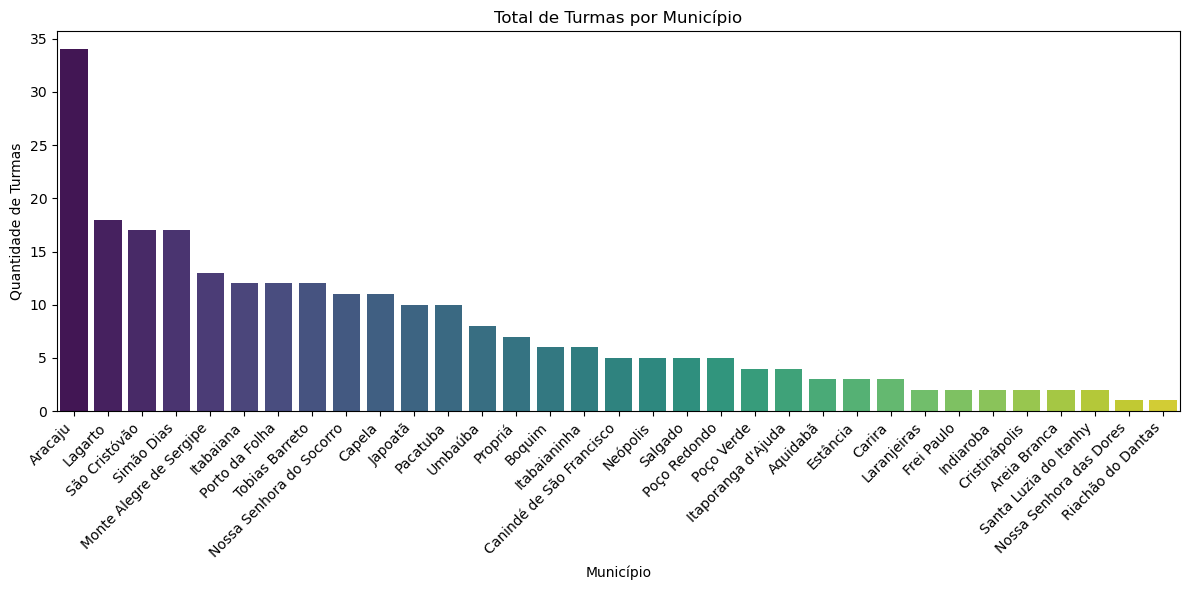

In [9]:
# Criando diretório para salvar os gráficos
output_dir_relatorio_21 = "Data_files/graficos_relatorio_2.1"
os.makedirs(output_dir_relatorio_21, exist_ok=True)

# Criando gráfico de total de turmas por município
plt.figure(figsize=(12, 6))
sns.barplot(data=turmas_por_unidade.sort_values('total_turmas', ascending=False),
            x='municipio', y='total_turmas', palette='viridis')
plt.title('Total de Turmas por Município')
plt.xlabel('Município')
plt.ylabel('Quantidade de Turmas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{output_dir_relatorio_21}/total_por_municipio.png', dpi=300)
plt.show()

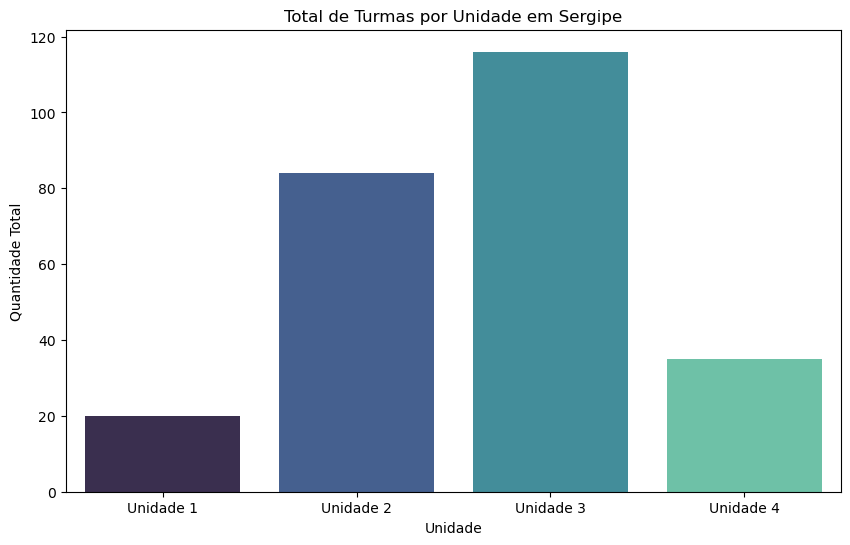

In [10]:
# Criando gráfico de total de turmas em cada unidade
# Gráfico 2: Total de turmas por unidade (com rótulos personalizados)
df_unidades = turmas_por_unidade.melt(
    id_vars=['municipio'],
    value_vars=['turmas_em_unid_1', 'turmas_em_unid_2', 'turmas_em_unid_3', 'turmas_em_unid_4'],
    var_name='Unidade',
    value_name='Quantidade'
)

# Mapear nomes das unidades
mapeamento_unidades = {
    'turmas_em_unid_1': 'Unidade 1',
    'turmas_em_unid_2': 'Unidade 2',
    'turmas_em_unid_3': 'Unidade 3',
    'turmas_em_unid_4': 'Unidade 4'
}
df_unidades['Unidade'] = df_unidades['Unidade'].map(mapeamento_unidades)

# Plotar o gráfico (sem warnings!)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_unidades,
    x='Unidade',
    y='Quantidade',
    hue='Unidade',      # Adicionado para evitar o warning
    estimator=sum,
    errorbar=None,
    palette='mako',
    legend=False        # Remove legenda redundante
)
plt.title('Total de Turmas por Unidade em Sergipe')
plt.xlabel('Unidade')
plt.ylabel('Quantidade Total')
plt.savefig(f'{output_dir_relatorio_21}/total_turmas_por_unidade_sergipe.png', dpi=300)
#plt.close()
plt.show()

In [11]:
# Criando um gráfico por município para mostrar número de turmas em cada unidade
# Criar um gráfico para cada município
for municipio in turmas_por_unidade['municipio'].unique():
    # Filtrar dados do município
    df_municipio = turmas_por_unidade[turmas_por_unidade['municipio'] == municipio]
    
    # Transformar os dados para formato longo (melt) e aplicar mapeamento
    df_melted = df_municipio.melt(
        id_vars=['municipio'], 
        value_vars=['turmas_em_unid_1', 'turmas_em_unid_2', 'turmas_em_unid_3', 'turmas_em_unid_4'],
        var_name='Unidade', 
        value_name='Quantidade'
    )
    
    # Aplicar os novos nomes das unidades
    df_melted['Unidade'] = df_melted['Unidade'].map(mapeamento_unidades)
    
    # Ordenar as unidades
    df_melted['Unidade'] = pd.Categorical(
        df_melted['Unidade'],
        categories=['Unidade 1', 'Unidade 2', 'Unidade 3', 'Unidade 4'],
        ordered=True
    )
    
    # Configurar o gráfico (versão atualizada do Seaborn)
    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=df_melted,
        x='Unidade',
        y='Quantidade',
        hue='Unidade',  # Adicionado para evitar o warning
        palette='rocket',
        legend=False    # Não mostra a legenda redundante
    )
    
    # Adicionar título e rótulos
    plt.title(f'Distribuição de Turmas em {municipio}')
    plt.xlabel('Unidade')
    plt.ylabel('Quantidade de Turmas')
    
    # Salvar o gráfico
    nome_arquivo = f"turmas_por_unidade_{municipio.lower().replace(' ', '_').replace('ã', 'a').replace('ç', 'c')}.png"
    plt.tight_layout()
    plt.savefig(f'{output_dir_relatorio_21}/{nome_arquivo}', dpi=300)
    plt.close()


### Atividades Estruturadas
Agora vamos entender os resultados das atividades estruturadas se apresentam considerando o programa como um todo.

#### Atividade Estruturada Diagnóstica

##### Estudando o estado como um todo

/tmp/ipykernel_69091/686031544.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_analise_diag_geral = df_registros_diag.groupby(['aprendizagem', 'nivel']).size().unstack(fill_value=0)


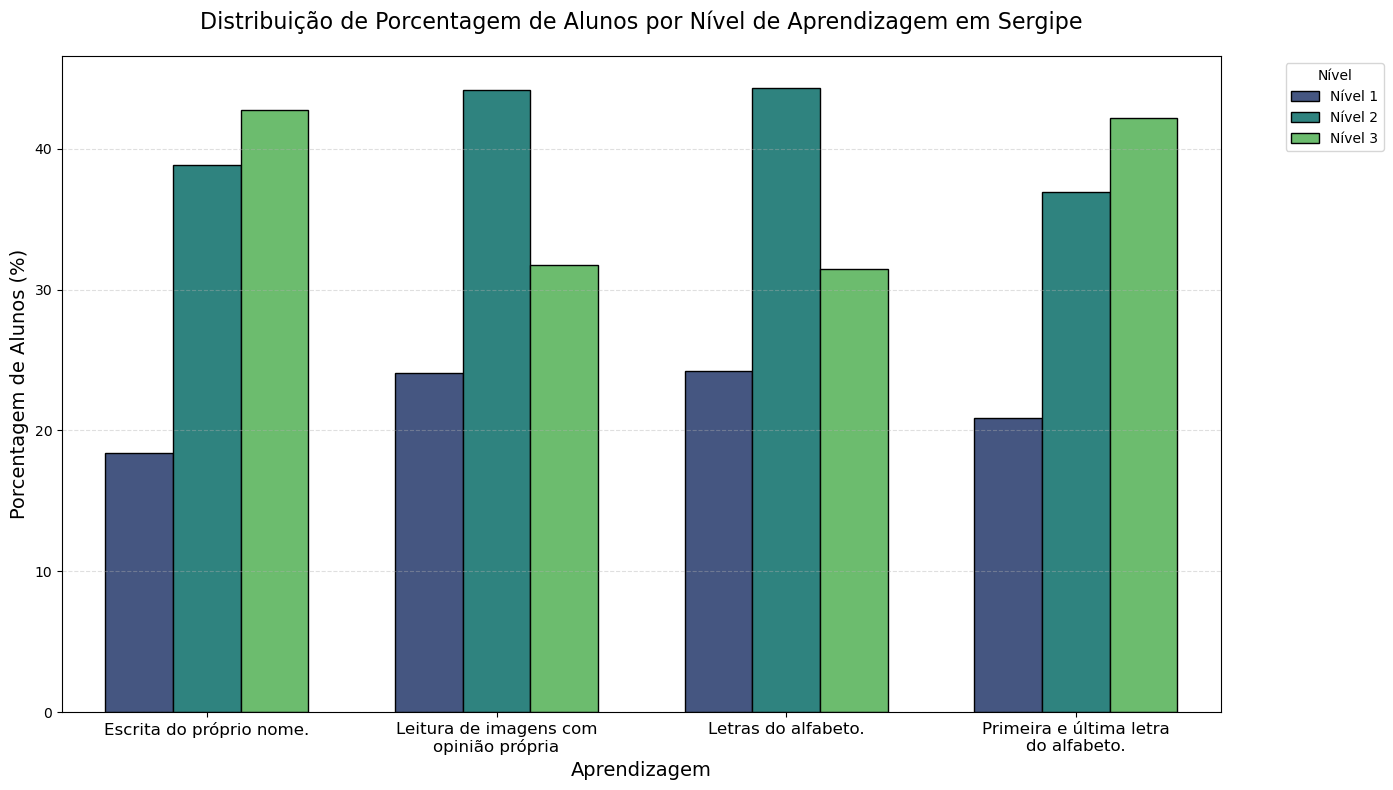

In [12]:
# Estudando a avaliação diagnóstica de Sergipe

# Agrupando dados de nível e prática de linguagem
df_analise_diag_geral = df_registros_diag.groupby(['aprendizagem', 'nivel']).size().unstack(fill_value=0)
df_analise_diag_geral['total'] = df_analise_diag_geral[['Nível 1', 'Nível 2', 'Nível 3']].sum(axis=1)

# Agrupando dados de nível em porcentagem
porcentagem_diag_nivel_estado = df_analise_diag_geral[['Nível 1', 'Nível 2', 'Nível 3']].div(df_analise_diag_geral['total'], axis=0) * 100


# Criando gráfico de barras para análise geral da avaliação diagnóstica
# Criando diretório para salvar os gráficos
output_dir = "Data_files/graficos_diagnostica"
os.makedirs(output_dir, exist_ok=True)

# 1. Preparar os dados (formato long)
df_long = porcentagem_diag_nivel_estado.reset_index().melt(
    id_vars='aprendizagem', 
    var_name='nivel', 
    value_name='contagem'
)

# 2. Definir quais rótulos serão quebrados em duas linhas
rotulos_quebrados = []
for rotulo in porcentagem_diag_nivel_estado.index:
    if rotulo == "Leitura de imagens com opinião própria":
        rotulo = "Leitura de imagens com\nopinião própria"
    elif rotulo == "Primeira e última letra do alfabeto.":
        rotulo = "Primeira e última letra\ndo alfabeto."
    rotulos_quebrados.append(rotulo)

# 3. Configurar o gráfico
plt.figure(figsize=(14, 8))  # Aumentei a altura para acomodar as quebras
ax = sns.barplot(
    data=df_long,
    x='aprendizagem',
    y='contagem',
    hue='nivel',
    palette='viridis',
    edgecolor='black',
    width=0.7  # Barras um pouco mais estreitas
)

# 4. Ajustar os rótulos do eixo X
ax.set_xticks(range(len(porcentagem_diag_nivel_estado.index)))
ax.set_xticklabels(
    rotulos_quebrados,  # Usa os rótulos modificados
    rotation=0,
    ha='center',
    fontsize=12,
    linespacing=1.2  # Espaçamento entre linhas
)

# 5. Ajustar margens e layout
plt.gcf().subplots_adjust(bottom=0.3)  # Mais espaço na parte inferior
plt.title('Distribuição de Porcentagem de Alunos por Nível de Aprendizagem em Sergipe', fontsize=16, pad=20)
plt.xlabel('Aprendizagem', fontsize=14)
plt.ylabel('Porcentagem de Alunos (%)', fontsize=14)
plt.legend(title='Nível', bbox_to_anchor=(1.05, 1), loc='upper left')

# 6. Adicionar grid para melhor leitura
plt.grid(axis='y', linestyle='--', alpha=0.4)

# 7. Salvar o gráfico
plt.savefig(os.path.join(output_dir, 'grafico_diagnostica_sergipe.png'), bbox_inches='tight', dpi=300)

# 8. Exibir o gráfico 
plt.tight_layout()
plt.show()

Observação: 

Gerando informações gerais sobre relatório de turmas

In [13]:
# Tratando dados de relatórios:
mapeamento_respostas = {
    'pergunta_1': {
        'Busca por novo emprego.': 'Busca\npor emprego'
    },
    'pergunta_3': {
        'Apresenta alta motivação e foco no aprendizado.': 'Muito interessado',
        'Demonstra interesse moderado, mas com dificuldades em manter o foco.': 'Interesse moderado',
        'Parcialmente. Realiza algumas atividades, mas ainda necessita de muita ajuda.': 'Parcialmente interessado',
        'Mostra-se desinteressado ou pouco motivado.': 'Desinteressado'
    },
    'pergunta_4': {
        'Parcialmente. Realiza algumas atividades, mas ainda necessita de muita ajuda.': 'Parcialmente',
        'Não. Somente com ajuda.': 'Não',
        'Sim. Alta autonomia, consegue executar as tarefas com pouca ou nenhuma orientação.': 'Sim',
        'Reconhece suas inseguranças, mas tenta superá-las.': 'Reconhece inseguranças',
        'Apresenta alta capacidade de enfrentar as dificuldades e seguir adiante.': 'Alta independência'
    },
    'pergunta_5': {
        'Reconhece suas inseguranças, mas tenta superá-las.': 'Reconhece inseguranças',
        'Demonstra insegurança evidente, evita atividades desafiadoras.': 'Insegurança evidente',
        'Apresenta alta capacidade de enfrentar as dificuldades e seguir adiante.': 'Alta independência',
        'Persiste e busca melhorar, encarando os erros como parte do processo.': 'Busca melhorar',
        'Participam ativamente, colaboram e interagem com os colegas': 'Participação ativa',
        'Persiste, mas demonstra frustração.': 'Persiste com frustração'
    },
    'pergunta_6': {
        'Persiste e busca melhorar, encarando os erros como parte do processo.': 'Busca melhorar',
        'Persiste, mas demonstra frustração.': 'Persiste com frustração',
        'Participam ativamente, colaboram e interagem com os colegas': 'Participação ativa',
        'Demonstra insegurança evidente, evita atividades desafiadoras.': 'Insegurança evidente',
        'Dificuldade significativa em leitura e escrita.': 'Dificuldade significativa',
    },
    'pergunta_7': {
        'Participam ativamente, colaboram e interagem com os colegas': 'Participação ativa',
        'Participam ocasionalmente, mas sem muita iniciativa.': 'Participação ocasional',
        'Dificuldades em algumas áreas.': 'Algumas dificuldades',
        'Dificuldade significativa em leitura e escrita.': 'Dificuldade significativa',
        'Facilidade em aplicar o aprendizado em diferentes contextos do cotidiano.': 'Facilidade de aplicação do aprendizado',
        'Consegue ler e escrever com confiança.': 'Confiança em leitura e escrita'
    },
    'pergunta_8': {
        'Dificuldade significativa em leitura e escrita.': 'Dificuldade significativa',
        'Consegue ler e escrever com confiança.': 'Confiança em leitura e escrita',
        'Facilidade em aplicar o aprendizado em diferentes contextos do cotidiano.': 'Facilidade de aplicação do aprendizado',
        'Alta valorização, percebe o impacto positivo do aprendizado em sua vida.': 'Alta valorização'
    },
    'pergunta_9': {
        'Dificuldade em aplicar o aprendizado.': 'Dificuldade em aplicar,',
        'Facilidade em aplicar o aprendizado em diferentes contextos do cotidiano.': 'Facilidade de aplicação',
        'Alta valorização, percebe o impacto positivo do aprendizado em sua vida.': 'Alta valorização',
        'Valoriza parcialmente, mas ainda tem dificuldades em ver utilidade prática.': 'Valoriza parcialmente'
    },
    'pergunta_10': {
        'Alta valorização, percebe o impacto positivo do aprendizado em sua vida.': 'Alta valorização',
        'Valoriza parcialmente, mas ainda tem dificuldades em ver utilidade prática.': 'Valoriza parcialmente'
    }
}

# Aplicar o mapeamento
for pergunta, mapeamento in mapeamento_respostas.items():
    if pergunta in df_relatorios_diagnostica.columns:
        df_relatorios_diagnostica[pergunta] = df_relatorios_diagnostica[pergunta].replace(mapeamento)
        

In [14]:
# Dicionário com os títulos descritivos
titulos_perguntas = {
    'pergunta_1': '1. O que os motiva a voltar a estudar?',
    'pergunta_2': '2. Quais as perspectivas das turmas quanto a alfabetização e letramento?',
    'pergunta_3': '3. Quanto ao interesse pelo processo de alfabetização,as turmas:',
    'pergunta_4': '4. As turmas conseguem realizar atividades de forma independente?',
    'pergunta_5': '5. O que as turmas fazem quando não entendem algo?',
    'pergunta_6': '6. Como as turmas reagem diante de erros ou falhas?',
    'pergunta_7': '7. Como as turmas se comportam durante atividades em grupo?',
    'pergunta_8': '8. Quanto a leitura de palavras simples e escrita de sílabas/letra, as turmas:',
    'pergunta_9': '9. Em relação a aplicação do conhecimento em situações práticas, as turmas:',
    'pergunta_10': '10. Como as turmas valorizam o saber no dia a dia?'
}

# Função para quebrar textos longos
def quebrar_texto(texto, max_length=15):
    if pd.isna(texto):
        return texto
    return '\n'.join(textwrap.wrap(str(texto), width=max_length))

# Configurações iniciais
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14

# 1. Preparação dos dados (igual ao anterior)
analise_perguntas = pd.DataFrame()
for pergunta in [f'pergunta_{i}' for i in range(1, 11)]:
    contagem = df_relatorios_diagnostica[pergunta].value_counts().reset_index()
    contagem.columns = ['resposta', 'contagem']
    contagem['porcentagem'] = (contagem['contagem'] / contagem['contagem'].sum()) * 100
    contagem['pergunta'] = pergunta
    contagem['resposta_formatada'] = contagem['resposta'].apply(quebrar_texto)
    analise_perguntas = pd.concat([analise_perguntas, contagem])

# 2. Gerar e salvar gráficos em arquivos separados
for file_num in range(5):
    fig, axes = plt.subplots(1, 2, figsize=(22, 12))
    plt.subplots_adjust(wspace=0.4, hspace=0.5)
    
    start_idx = file_num * 2
    end_idx = start_idx + 2
    
    for i, pergunta in enumerate([f'pergunta_{j}' for j in range(start_idx+1, end_idx+1)]):
        dados = analise_perguntas[analise_perguntas['pergunta'] == pergunta].sort_values('porcentagem', ascending=False)
        
        # Gráfico Seaborn - REMOVER RÓTULOS DO EIXO X
        ax = sns.barplot(
            data=dados,
            x='resposta_formatada',
            y='porcentagem',
            hue='resposta_formatada',
            palette='viridis',
            dodge=False,
            ax=axes[i],
            legend=False
        )
        
        # Remover rótulos do eixo X
        ax.set_xticklabels([])
        ax.set_xlabel('')
        
        # Títulos e labels
        ax.set_title(titulos_perguntas[pergunta], fontsize=18, pad=25)
        ax.set_ylabel('Porcentagem (%)', fontsize=14)
        
        # Ajustar eixo y
        ax.set_ylim(0, min(100, dados['porcentagem'].max() * 1.2))
        sns.despine(left=True)
        
        # Adicionar valores nas barras
        for p in ax.patches:
            ax.annotate(
                f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 8),
                textcoords='offset points',
                fontsize=14
            )
        
        # CRIAR LEGENDA NA ÁREA VAZIA
        handles = [plt.Rectangle((0,0),1,1, color=color) for color in sns.color_palette("viridis", len(dados))]
        ax.legend(
            handles=handles,
            labels=list(dados['resposta_formatada']),
            title='Respostas',
            bbox_to_anchor=(0.9, 0.9),  # Posição relativa ao gráfico
            loc='upper left',
            borderaxespad=0.,
            frameon=True,
            fontsize=14,
            title_fontsize=16
        )
        
        ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Salvar figura
    output_path = os.path.join(output_dir, f'graficos_relatorio_diag_{file_num+1}.png')
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.close()

print(f"✅ Gráficos salvos em: {os.path.abspath(output_dir)}")
analise_perguntas.sort_values(['pergunta', 'porcentagem'], ascending=[True, False])


/tmp/ipykernel_69091/3771903758.py:101: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/tmp/ipykernel_69091/3771903758.py:101: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


✅ Gráficos salvos em: /home/fabcmc/GitHub Files/FGV/pba_se_2025/Data_files/graficos_diagnostica


,resposta,contagem,porcentagem,pergunta,resposta_formatada
0,Desejo de aprender.,263,94.265233,pergunta_1,Desejo de\naprender.
1,Incentivo da família.,9,3.225806,pergunta_1,Incentivo da\nfamília.
2,Busca\npor emprego,3,1.075269,pergunta_1,Busca por\nemprego
3,Outros: ter a dignidade restaurada através da ...,1,0.358423,pergunta_1,Outros: ter a\ndignidade\nrestaurada\natravés ...
4,Outros: A maioria porque não sabe escrever o p...,1,0.358423,pergunta_1,Outros: A\nmaioria porque\nnão sabe\nescrever ...
...,...,...,...,...,...
1,"Dificuldade em aplicar,",53,19.133574,pergunta_9,"Dificuldade em\naplicar,"
2,Facilidade de aplicação,49,17.689531,pergunta_9,Facilidade de\naplicação
3,Valoriza parcialmente,4,1.444043,pergunta_9,Valoriza\nparcialmente
4,Alta valorização,3,1.083032,pergunta_9,Alta\nvalorização


##### Estudando os dados por estado
Agora vamos entender os dados de cada município. Dessa forma, nosso objetivo aqui é:
- Entender a quantidade de alunos por município e sua proporção em relação ao programa como um todo;
- Entender a quantidade de turmas por município e sua proporção em relação ao programa como um todo;
- Entender a relevância dos alunos perante o total de alunos enturmados em Sergipe;
- Gerar os resultados dos registros por atividade estruturada por município;
- Gerar os resultados de perfil de turma por município e entender se os perfis são diferentes.

##### Entendendo alunos e turmas por município


In [15]:
# Criar uma cópia para trabalhar sem modificar o original
df_trabalho = df_cadastro.copy()

# Certificando que 'turma' tem o mesmo tipo em ambos os DataFrames
df_trabalho['turma'] = df_trabalho['turma'].astype(str).str.strip()
df_turmas['turma'] = df_turmas['turma'].astype(str).str.strip()

# Executando o merge
df_trabalho = df_trabalho.merge(
    df_turmas[['turma', 'municipio']], 
    on='turma', 
    how='left'
)

# Contando número de alunos e turmas por município
df_dados_municipios = df_trabalho.groupby('municipio').agg(
    numero_alunos=('nome', 'count'),
    numero_turmas=('turma', 'nunique')
).reset_index()

# Calculando média de alunos por turma por município e entendendo a relevância de cada município perante ao total de alunos enturmados
df_dados_municipios['media_alunos_por_turma'] = df_dados_municipios['numero_alunos'] / df_dados_municipios['numero_turmas']
df_dados_municipios['relevancia'] = df_dados_municipios['numero_alunos'] * 100 / enturmados

# Separando número de alunos por turma em cada município
turmas_e_municipios = df_turmas[['turma', 'municipio']]
turmas_e_municipios = turmas_e_municipios.rename(columns={'qtd._alfabetizandos': 'total_turma'})

# Entendendo quantidade de alunos em cada nível por turma em cada município
contagem_alunos_turma_diag = df_registros_diag.groupby('turma')['nome'].nunique().reset_index()
contagem_diag_turma = df_registros_diag.groupby(['turma', 'aprendizagem', 'nivel']).size().unstack(fill_value=0).reset_index()
contagem_diag_turma['total_turma'] = contagem_diag_turma[['Nível 1', 'Nível 2', 'Nível 3']].sum(axis=1)
contagem_diag_turma = contagem_diag_turma.merge(turmas_e_municipios, on='turma', how='left')
contagem_diag_municipio = contagem_diag_turma.groupby(['municipio', 'turma', 'total_turma', 'aprendizagem'])[['Nível 1', 'Nível 2', 'Nível 3']].sum().reset_index()

contagem_diag_municipio.head()


/tmp/ipykernel_69091/717688300.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  contagem_diag_turma = df_registros_diag.groupby(['turma', 'aprendizagem', 'nivel']).size().unstack(fill_value=0).reset_index()


,municipio,turma,total_turma,aprendizagem,Nível 1,Nível 2,Nível 3
0,AQUIDABÃ,TURMA-28005201-0003,10,Escrita do próprio nome.,2,2,6
1,AQUIDABÃ,TURMA-28005201-0003,10,Leitura de imagens com opinião própria,0,2,8
2,AQUIDABÃ,TURMA-28005201-0003,10,Letras do alfabeto.,3,6,1
3,AQUIDABÃ,TURMA-28005201-0003,10,Primeira e última letra do alfabeto.,3,3,4
4,AQUIDABÃ,TURMA-28005201-0004,16,Escrita do próprio nome.,11,4,1


Agora vamos classificar os municipios de acordo com as médias em nível 3 em ordem decrescente e entender quais municipios apresentam maiores valores de nível 3. Nosso objetivo é tentar entender se há um padrão geográfico.

/tmp/ipykernel_69091/1607288993.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  porcentagem_diag_nivel_municipio = contagem_diag_municipio.groupby(['municipio', 'aprendizagem']).apply(



Erro ao processar 'Escrita do próprio nome': The EPSG code is unknown. PROJ: internal_proj_create_from_database: /home/fabcmc/anaconda3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.


ERROR 1: PROJ: internal_proj_create_from_database: /home/fabcmc/anaconda3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.



Erro ao processar 'Leitura de imagens': The EPSG code is unknown. PROJ: internal_proj_create_from_database: /home/fabcmc/anaconda3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.


ERROR 1: PROJ: internal_proj_create_from_database: /home/fabcmc/anaconda3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.



Erro ao processar 'Letras do alfabeto': The EPSG code is unknown. PROJ: internal_proj_create_from_database: /home/fabcmc/anaconda3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.


ERROR 1: PROJ: internal_proj_create_from_database: /home/fabcmc/anaconda3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.



Erro ao processar 'Primeira e última letra': The EPSG code is unknown. PROJ: internal_proj_create_from_database: /home/fabcmc/anaconda3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.


ERROR 1: PROJ: internal_proj_create_from_database: /home/fabcmc/anaconda3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.


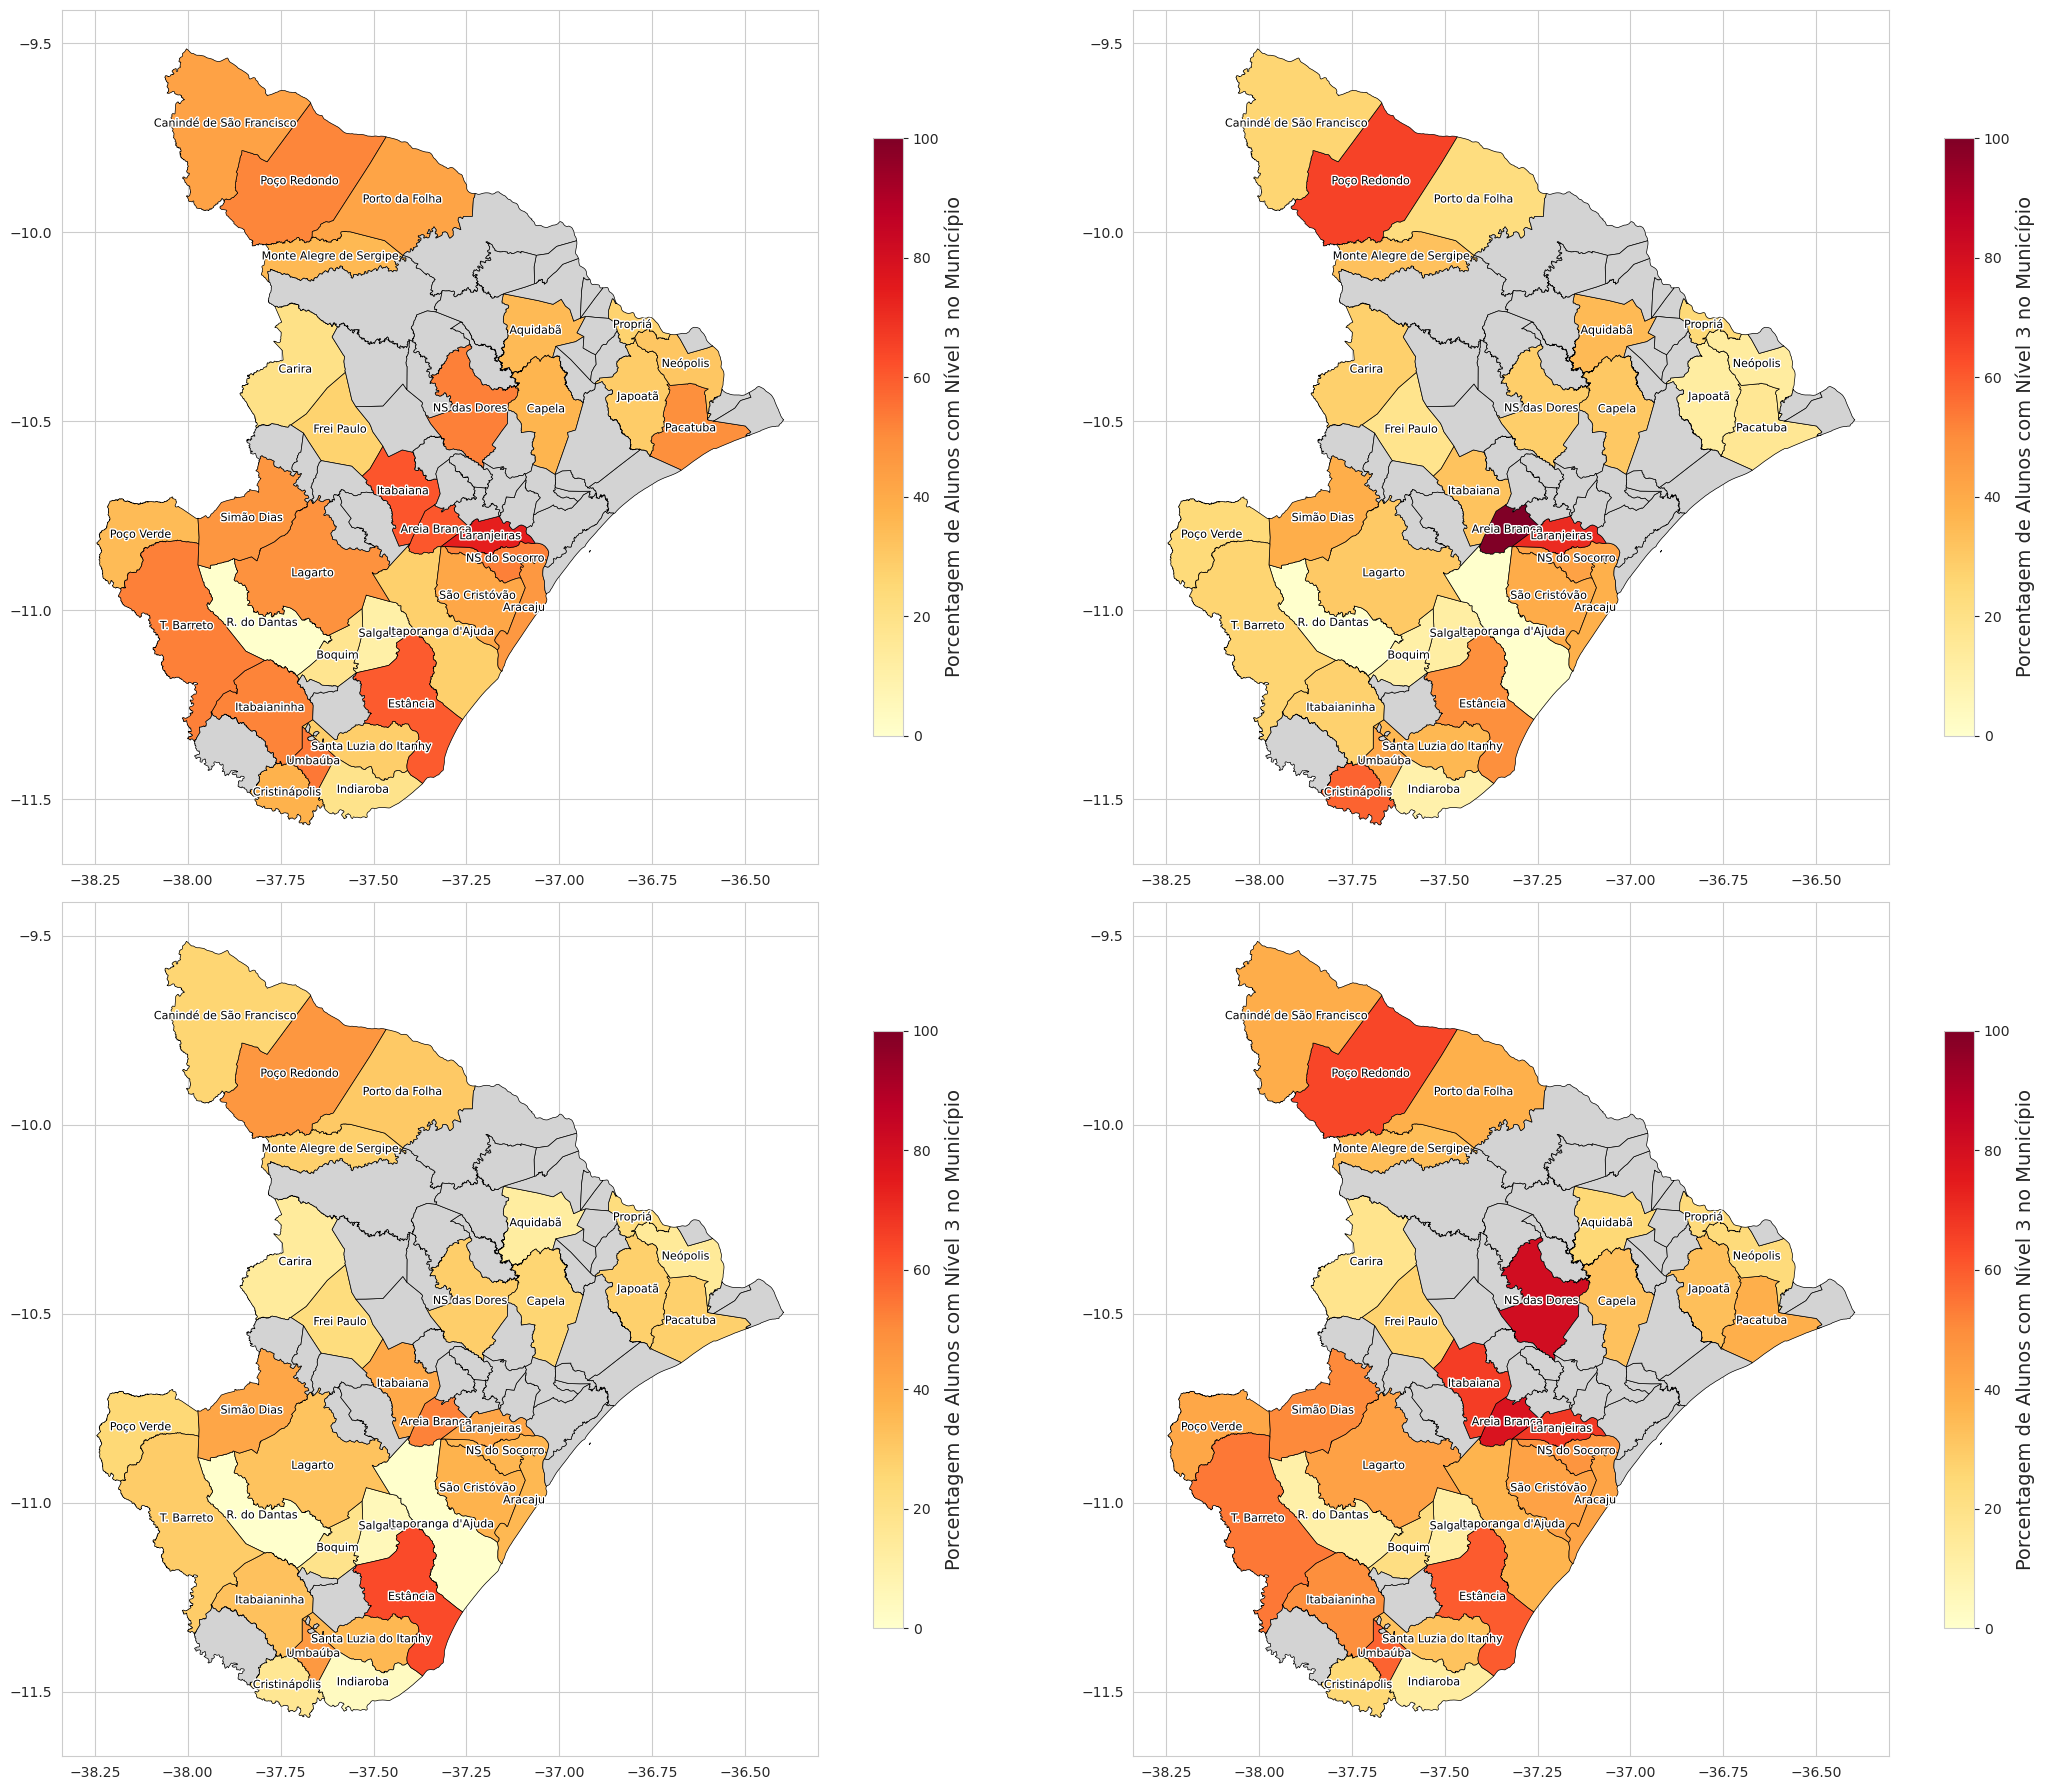

In [16]:
# Função para padronizar nomes de municípios
def padronizar_nomes(texto):
    return (
        texto.str.upper()
        .str.normalize('NFKD')  # Remove acentos
        .str.encode('ascii', errors='ignore')  # Converte para ASCII
        .str.decode('utf-8')  # Volta para UTF-8
        .str.replace(" DE ", " ")
        .str.replace(" DA ", " ")
        .str.replace(" DO ", " ")
        .str.strip()
    )

# 1. Cálculo das porcentagens (seu código original)
porcentagem_diag_nivel_municipio = contagem_diag_municipio.groupby(['municipio', 'aprendizagem']).apply(
    lambda x: pd.Series({
        'porcentagem_nivel_1': (x['Nível 1'].sum() * 100) / x['total_turma'].sum(),
        'porcentagem_nivel_2': (x['Nível 2'].sum() * 100) / x['total_turma'].sum(),
        'porcentagem_nivel_3': (x['Nível 3'].sum() * 100) / x['total_turma'].sum()
    })
).reset_index()

# 2. Classificação (seu código original)
primeira_e_ultima_letra = porcentagem_diag_nivel_municipio[
    porcentagem_diag_nivel_municipio['aprendizagem'] == 'Primeira e última letra do alfabeto.'].sort_values(by='porcentagem_nivel_3', ascending=False)
letras_do_alfabeto = porcentagem_diag_nivel_municipio[
    porcentagem_diag_nivel_municipio['aprendizagem'] == 'Letras do alfabeto.'].sort_values(by='porcentagem_nivel_3', ascending=False)
leitura_de_imagens = porcentagem_diag_nivel_municipio[
    porcentagem_diag_nivel_municipio['aprendizagem'] == 'Leitura de imagens com opinião própria'].sort_values(by='porcentagem_nivel_3', ascending=False)
escrita_do_nome = porcentagem_diag_nivel_municipio[
    porcentagem_diag_nivel_municipio['aprendizagem'] == 'Escrita do próprio nome.'].sort_values(by='porcentagem_nivel_3', ascending=False)

# 3. Padronização dos nomes ANTES da mesclagem
dfs_aprendizagens = [escrita_do_nome, leitura_de_imagens, letras_do_alfabeto, primeira_e_ultima_letra]

# Carregar shapefile
sergipe = gpd.read_file('Data_files/SE_Municipios_2024/SE_Municipios_2024.shp')

# Padronizar nomes no shapefile e nos DataFrames
sergipe['NM_MUN_PADRONIZADO'] = padronizar_nomes(sergipe['NM_MUN'])

for df in dfs_aprendizagens:
    df['municipio_padronizado'] = padronizar_nomes(df['municipio'])

# Função para abreviar "Nossa Senhora" para "NS"
def abreviar_nome(nome):
    return nome.replace(
        "Nossa Senhora", "NS").replace(
            "N.S.", "NS").replace(
                "Tobias Barreto", "T. Barreto").replace(
                    "Riachão do Dantas", "R. do Dantas")

# 4. Configuração dos plots
fig, axes = plt.subplots(2, 2, figsize=(22, 18))
axes = axes.flatten()

titulos = [
    'Escrita do próprio nome',
    'Leitura de imagens',
    'Letras do alfabeto',
    'Primeira e última letra'
]

# Loop para cada aprendizagem
for i, (df, titulo) in enumerate(zip(dfs_aprendizagens, titulos)):
    try:
        # Mesclagem com nomes padronizados
        sergipe_merged = sergipe.merge(
            df,
            left_on='NM_MUN_PADRONIZADO',
            right_on='municipio_padronizado',
            how='left'
        )
        
        # Plotagem
        ax = axes[i]
        sergipe_merged.plot(
            column='porcentagem_nivel_3',
            cmap='YlOrRd',
            legend=True,
            ax=ax,
            edgecolor='black',
            linewidth=0.5,
            missing_kwds={'color': 'lightgrey'},
            vmin=0,
            vmax=100,
            legend_kwds={'label': "Porcentagem de Alunos com Nível 3 no Município", 'shrink': 0.7}
        )
        
        # ADIÇÃO DOS NOMES DOS MUNICÍPIOS COM ABREVIAÇÃO
        for idx, row in sergipe_merged.iterrows():
            if not pd.isna(row['porcentagem_nivel_3']):
                nome_municipio = abreviar_nome(row['NM_MUN'])
                ax.annotate(
                    text=nome_municipio,  # Nome abreviado quando aplicável
                    xy=row['geometry'].centroid.coords[0],
                    ha='center',
                    va='center',
                    fontsize=8,
                    color='black',
                    path_effects=[patheffects.withStroke(linewidth=2, foreground="white")]
                )
        
        ctx.add_basemap(ax, crs=sergipe.crs, source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.7)
        ax.set_title(f'Desempenho em {titulo} - % de Alunos com Nível 3', fontsize=14)
        ax.set_axis_off()
        
    except Exception as e:
        print(f"\nErro ao processar '{titulo}': {str(e)}")
        continue

plt.tight_layout()
plt.savefig(os.path.join(output_dir,'heatmaps_sergipe_diag.png'), dpi=300, bbox_inches='tight')

A partir desses resultados, vamos gerar os gráficos por município e entender a variabilidade dos dados através da barra de erro.

##### Criando gráficos e exportando para relatórios

In [17]:
# Lista de municípios únicos
municipios = df_registros_diag['municipio'].unique()


# Criando loop para gerar gráficos
for municipio in municipios:
    # Filtrar dados para o município atual
    df_municipio = df_registros_diag[df_registros_diag['municipio'] == municipio]
    
    # Agrupar dados (igual ao seu processamento original)
    df_analise = df_municipio.groupby(['aprendizagem', 'nivel']).size().unstack(fill_value=0)
    df_analise['total'] = df_analise[['Nível 1', 'Nível 2', 'Nível 3']].sum(axis=1)
    
    # Agrupado dados em porcentagem
    porcentagem_nivel = df_analise[['Nível 1', 'Nível 2', 'Nível 3']].div(df_analise['total'], axis=0) * 100    
    
    # Preparar dados no formato longo
    df_long = porcentagem_nivel.reset_index().melt(
        id_vars='aprendizagem',
        var_name='nivel',
        value_name='contagem'
    )
    
    # Quebra de rótulos específicos (igual ao anterior)
    rotulos_quebrados = []
    for rotulo in porcentagem_nivel.index:
        if rotulo == "Leitura de imagens com opinião própria":
            rotulo = "Leitura de imagens com\nopinião própria"
        elif rotulo == "Primeira e última letra do alfabeto":
            rotulo = "Primeira e última letra\ndo alfabeto."
        rotulos_quebrados.append(rotulo)
    
    # Criar figura
    plt.figure(figsize=(14, 8))
    ax = sns.barplot(
        data=df_long,
        x='aprendizagem',
        y='contagem',
        hue='nivel',
        palette='viridis',
        edgecolor='black',
        width=0.7
    )
    
    # Formatação do gráfico
    ax.set_xticklabels(rotulos_quebrados, rotation=0, ha='center', fontsize=12, linespacing=1.2)
    plt.title(f'Distribuição por Nível de Aprendizagem\nMunicípio: {municipio}', fontsize=16, pad=20)
    plt.xlabel('Aprendizagem', fontsize=14)
    plt.ylabel('Porcentagem de Alunos (%)', fontsize=14)
    plt.legend(title='Nível', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    
    # Salvar o gráfico
    nome_arquivo = f'grafico_diagnostica_{municipio.lower().replace(" ", "_")}.png'
    caminho_completo = os.path.join(output_dir, nome_arquivo)
    
    plt.savefig(
        caminho_completo,
        dpi=300,
        bbox_inches='tight',
        facecolor='white'
    )
    
    plt.close()  # Fecha a figura para liberar memória
    
    print(f'Gráfico salvo: {caminho_completo}')

print("Processo concluído! Todos os gráficos foram gerados.")


/tmp/ipykernel_69091/842642549.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_analise = df_municipio.groupby(['aprendizagem', 'nivel']).size().unstack(fill_value=0)
/tmp/ipykernel_69091/842642549.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rotulos_quebrados, rotation=0, ha='center', fontsize=12, linespacing=1.2)


Gráfico salvo: Data_files/graficos_diagnostica/grafico_diagnostica_simão_dias.png


/tmp/ipykernel_69091/842642549.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_analise = df_municipio.groupby(['aprendizagem', 'nivel']).size().unstack(fill_value=0)
/tmp/ipykernel_69091/842642549.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rotulos_quebrados, rotation=0, ha='center', fontsize=12, linespacing=1.2)


Gráfico salvo: Data_files/graficos_diagnostica/grafico_diagnostica_aracaju.png


/tmp/ipykernel_69091/842642549.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_analise = df_municipio.groupby(['aprendizagem', 'nivel']).size().unstack(fill_value=0)
/tmp/ipykernel_69091/842642549.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rotulos_quebrados, rotation=0, ha='center', fontsize=12, linespacing=1.2)


...

Gráfico salvo: Data_files/graficos_diagnostica/grafico_diagnostica_nossa_senhora_das_dores.png


/tmp/ipykernel_69091/842642549.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_analise = df_municipio.groupby(['aprendizagem', 'nivel']).size().unstack(fill_value=0)
/tmp/ipykernel_69091/842642549.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rotulos_quebrados, rotation=0, ha='center', fontsize=12, linespacing=1.2)


Gráfico salvo: Data_files/graficos_diagnostica/grafico_diagnostica_riachão_do_dantas.png


/tmp/ipykernel_69091/842642549.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_analise = df_municipio.groupby(['aprendizagem', 'nivel']).size().unstack(fill_value=0)
/tmp/ipykernel_69091/842642549.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rotulos_quebrados, rotation=0, ha='center', fontsize=12, linespacing=1.2)


Gráfico salvo: Data_files/graficos_diagnostica/grafico_diagnostica_cristinápolis.png
Processo concluído! Todos os gráficos foram gerados.


#### Atividade Estruturada Formativa 1

Primeiramente, vamos construir uma tabela contando as quantidades de cada nível para cada formativa, considerando a linguagem, municipio e a turma.

In [18]:
# Calculando moda dos níveis para cada linguagem
def calcular_moda_nivel(df, form_number):
    """
    Calcula a moda da coluna 'nivel' para um dataframe de formulário específico.
    
    Args:
        df: DataFrame com os registros do formulário
        form_number: Número do formulário (1, 2 ou 3)
    
    Returns:
        DataFrame com as modas calculadas
    """
    moda_df = (
        df.groupby(['cpf', 'nome', 'turma', 'municipio', 'linguagem'])['nivel']
        .agg(lambda x: x.mode().iloc[0])
        .reset_index()
    )
    return moda_df

# Calcular modas para cada formulário
moda_form_1 = calcular_moda_nivel(df_registros_form_1, 1)
moda_form_2 = calcular_moda_nivel(df_registros_form_2, 2)
moda_form_3 = calcular_moda_nivel(df_registros_form_3, 3)

# Contando níveis por formativa
def contar_niveis_por_form(df, form_number):
    # Conta a ocorrência de cada nível, mantendo as colunas de agrupamento
    # Adicionando observed=True para evitar o warning
    contagem = (
        df.groupby(['turma', 'municipio', 'linguagem', 'nivel'], observed=True)
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )
    
    # Renomeia as colunas de nível para incluir o número do formulário
    nivel_cols = [col for col in contagem.columns if col not in ['turma', 'municipio', 'linguagem']]
    rename_dict = {col: f'form_{form_number}_{col}' for col in nivel_cols}
    contagem = contagem.rename(columns=rename_dict)
    
    return contagem

# Aplicar a função para cada formulário
contagem_form_1 = contar_niveis_por_form(moda_form_1, 1)
contagem_form_2 = contar_niveis_por_form(moda_form_2, 2)
contagem_form_3 = contar_niveis_por_form(moda_form_3, 3)

# Combinar os resultados com outer join
df_contagem_completa = (
    contagem_form_1
    .merge(contagem_form_2, 
           on=['turma', 'municipio', 'linguagem'], 
           how='outer',
           suffixes=('', '_form2'))
    .merge(contagem_form_3, 
           on=['turma', 'municipio', 'linguagem'],
           how='outer',
           suffixes=('', '_form3'))
    .fillna(0)
)

# Limpeza final dos nomes das colunas
df_contagem_completa.columns = [col.replace('_form2', '_form_2').replace('_form3', '_form_3') 
                               for col in df_contagem_completa.columns]

# Ordenação final
df_contagem_completa = df_contagem_completa.sort_values(
    by=['turma', 'municipio', 'linguagem']
).reset_index(drop=True)

# Separando por linguagem
df_analise_linguistica = df_contagem_completa[df_contagem_completa['linguagem'] == 'Análise linguística'].drop(['form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3'], axis=1).reset_index(drop=True)
df_oralidade_leitura = df_contagem_completa[df_contagem_completa['linguagem'] == 'Oralidade e leitura'].drop(['form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3'], axis=1).reset_index(drop=True)

# Contando número total de alunos por turma com base na Formativa 1
df_analise_linguistica['total_alunos_form_1'] = df_analise_linguistica[['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3']].sum(axis=1)
df_analise_linguistica['total_alunos_form_2'] = df_analise_linguistica[['form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3']].sum(axis=1)
df_oralidade_leitura['total_alunos_form_1'] = df_oralidade_leitura[['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3']].sum(axis=1)
df_oralidade_leitura['total_alunos_form_3'] = df_oralidade_leitura[['form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3']].sum(axis=1)

# Retirando turmas que não contém dados
df_analise_linguistica = df_analise_linguistica[df_analise_linguistica['turma'].isin(ls_turmas_unid_3)]
df_oralidade_leitura = df_oralidade_leitura[df_oralidade_leitura['turma'].isin(ls_turmas_unid_4)]

df_oralidade_leitura.info()


<class 'pandas.core.frame.DataFrame'>
Index: 36 entries, 5 to 227
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   turma                36 non-null     object 
 1   municipio            36 non-null     object 
 2   linguagem            36 non-null     object 
 3   form_1_Nível 1       36 non-null     float64
 4   form_1_Nível 2       36 non-null     float64
 5   form_1_Nível 3       36 non-null     float64
 6   form_3_Nível 1       36 non-null     float64
 7   form_3_Nível 2       36 non-null     float64
 8   form_3_Nível 3       36 non-null     float64
 9   total_alunos_form_1  36 non-null     float64
 10  total_alunos_form_3  36 non-null     float64
dtypes: float64(8), object(3)
memory usage: 3.4+ KB


In [19]:
# Informações de Formativa 1 de municípios

df_valores_form_1 = moda_form_1[moda_form_1['turma'].isin(ls_turmas_unid_2)].reset_index(drop=True)

count_valores_form_1 = df_valores_form_1.groupby(['municipio', 'linguagem', 'nivel']).size().unstack(fill_value=0)

count_valores_form_1['total'] = count_valores_form_1[['Nível 1', 'Nível 2', 'Nível 3']].sum(axis=1)

moda_form_1.head()

/tmp/ipykernel_69091/867261129.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_valores_form_1 = df_valores_form_1.groupby(['municipio', 'linguagem', 'nivel']).size().unstack(fill_value=0)


,cpf,nome,turma,municipio,linguagem,nivel
0,012.479.683-40,Dr. Henry Gabriel Brito,TURMA-28022394-0004,Cristinápolis,Análise linguística,Nível 2
1,012.479.683-40,Dr. Henry Gabriel Brito,TURMA-28022394-0004,Cristinápolis,Oralidade e leitura,Nível 3
2,012.536.974-34,Ana Clara Martins,TURMA-28008804-0005,Poço Verde,Análise linguística,Nível 2
3,012.536.974-34,Ana Clara Martins,TURMA-28008804-0005,Poço Verde,Oralidade e leitura,Nível 2
4,012.637.498-87,Isabel Silveira,TURMA-28031547-0002,Itabaiana,Análise linguística,Nível 3


In [20]:
# Lista de municípios únicos
municipios_form_1 = moda_form_1['municipio'].unique()


# Criando loop para gerar gráficos
for municipio in municipios_form_1:
    # Filtrar dados para o município atual
    df_municipio = moda_form_1[moda_form_1['municipio'] == municipio]
    
    # Agrupar dados (igual ao seu processamento original)
    df_analise = df_municipio.groupby(['linguagem', 'nivel']).size().unstack(fill_value=0)
    df_analise['total'] = df_analise[['Nível 1', 'Nível 2', 'Nível 3']].sum(axis=1)
    
    # Agrupado dados em porcentagem
    porcentagem_nivel = df_analise[['Nível 1', 'Nível 2', 'Nível 3']].div(df_analise['total'], axis=0) * 100    
    
    # Preparar dados no formato longo
    df_long = porcentagem_nivel.reset_index().melt(
        id_vars='linguagem',
        var_name='nivel',
        value_name='contagem'
    )
    
    # Quebra de rótulos específicos (igual ao anterior)
    rotulos_quebrados = []
    for rotulo in porcentagem_nivel.index:
        if rotulo == "Análise linguística":
            rotulo = "Análise\nlinguística"
        elif rotulo == "Oralidade e leitura":
            rotulo = "Oralidade\ne leitura"
        rotulos_quebrados.append(rotulo)
    
    # Criar figura
    plt.figure(figsize=(14, 8))
    ax = sns.barplot(
        data=df_long,
        x='linguagem',
        y='contagem',
        hue='nivel',
        palette='rocket',
        edgecolor='black',
        width=0.7
    )
    
    # Formatação do gráfico
    ax.set_xticklabels(rotulos_quebrados, rotation=0, ha='center', fontsize=12, linespacing=1.2)
    plt.title(f'Distribuição por Nível em Formativa 1\nMunicípio: {municipio}', fontsize=16, pad=20)
    plt.xlabel('Linguagem', fontsize=14)
    plt.ylabel('Porcentagem de Alunos (%)', fontsize=14)
    plt.legend(title='Nível', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    
    # Salvar o gráfico
    nome_arquivo = f'grafico_form_1_{municipio.lower().replace(" ", "_")}.png'
    caminho_completo = os.path.join(output_dir_relatorio_21, nome_arquivo)
    
    plt.savefig(
        caminho_completo,
        dpi=300,
        bbox_inches='tight',
        facecolor='white'
    )
    
    plt.close()  # Fecha a figura para liberar memória
    
    print(f'Gráfico salvo: {caminho_completo}')

print("Processo concluído! Todos os gráficos foram gerados.")

/tmp/ipykernel_69091/666554247.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_analise = df_municipio.groupby(['linguagem', 'nivel']).size().unstack(fill_value=0)
/tmp/ipykernel_69091/666554247.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rotulos_quebrados, rotation=0, ha='center', fontsize=12, linespacing=1.2)


Gráfico salvo: Data_files/graficos_relatorio_2.1/grafico_form_1_cristinápolis.png


/tmp/ipykernel_69091/666554247.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_analise = df_municipio.groupby(['linguagem', 'nivel']).size().unstack(fill_value=0)
/tmp/ipykernel_69091/666554247.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rotulos_quebrados, rotation=0, ha='center', fontsize=12, linespacing=1.2)


Gráfico salvo: Data_files/graficos_relatorio_2.1/grafico_form_1_poço_verde.png


/tmp/ipykernel_69091/666554247.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_analise = df_municipio.groupby(['linguagem', 'nivel']).size().unstack(fill_value=0)
/tmp/ipykernel_69091/666554247.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rotulos_quebrados, rotation=0, ha='center', fontsize=12, linespacing=1.2)


...

Gráfico salvo: Data_files/graficos_relatorio_2.1/grafico_form_1_umbaúba.png


/tmp/ipykernel_69091/666554247.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_analise = df_municipio.groupby(['linguagem', 'nivel']).size().unstack(fill_value=0)
/tmp/ipykernel_69091/666554247.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rotulos_quebrados, rotation=0, ha='center', fontsize=12, linespacing=1.2)


Gráfico salvo: Data_files/graficos_relatorio_2.1/grafico_form_1_boquim.png


/tmp/ipykernel_69091/666554247.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_analise = df_municipio.groupby(['linguagem', 'nivel']).size().unstack(fill_value=0)
/tmp/ipykernel_69091/666554247.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rotulos_quebrados, rotation=0, ha='center', fontsize=12, linespacing=1.2)


Gráfico salvo: Data_files/graficos_relatorio_2.1/grafico_form_1_nossa_senhora_das_dores.png
Processo concluído! Todos os gráficos foram gerados.


#### Teste estatístico


=== ANÁLISE CONSIDERANDO ANÁLISE LINGUÍSTICA PARA TODO O ESTADO DE SERGIPE ===

Teste de Wilcoxon para Nível 1:
Estatística = 973.500, p-valor = 0.0000
Há diferença significativa (p < 0.05) nas proporções de Nível 1 entre os testes.
A proporção de alunos no Nível 1 DIMINUIU significativamente no teste 2.
---
Teste de Wilcoxon para Nível 2:
Estatística = 1790.000, p-valor = 0.0010
Há diferença significativa (p < 0.05) nas proporções de Nível 2 entre os testes.
A proporção de alunos no Nível 2 DIMINUIU significativamente no teste 2.
---
Teste de Wilcoxon para Nível 3:
Estatística = 809.000, p-valor = 0.0000
Há diferença significativa (p < 0.05) nas proporções de Nível 3 entre os testes.
A proporção de alunos no Nível 3 AUMENTOU significativamente no teste 2.
---

=== ANÁLISE CONSIDERANDO ANÁLISE LINGUÍSTICA POR MUNICÍPIO ===


Município: Canindé de São Francisco

Nível 1:
Estatística = 0.000, p-valor = 0.0625
Não há diferença significativa (p ≥ 0.05) em Canindé de São Francisco.

Nível 

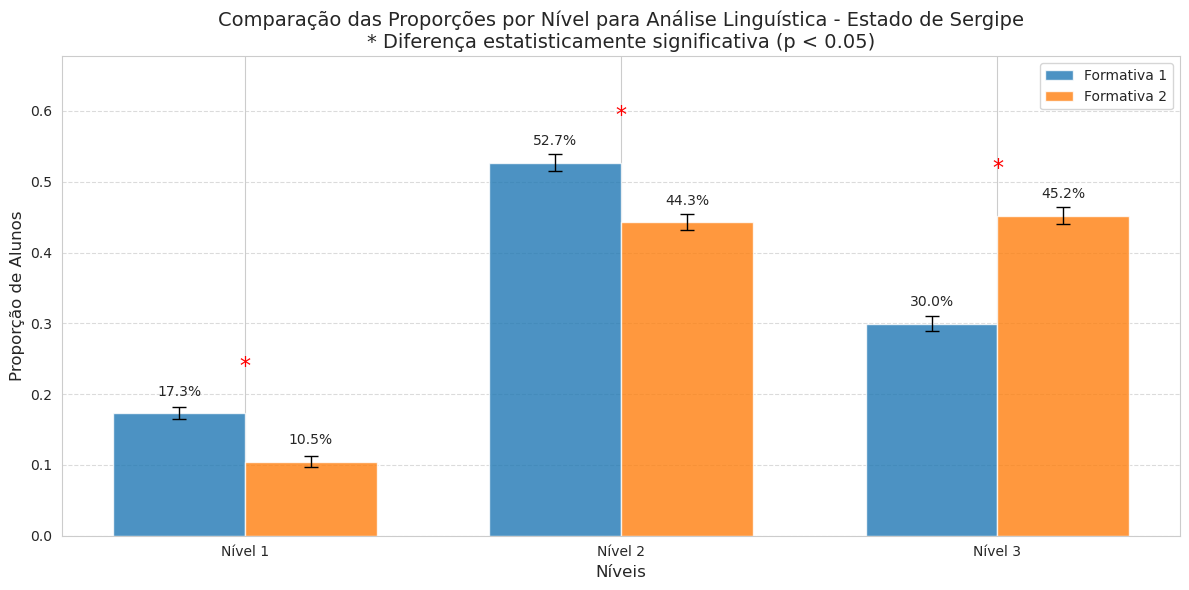

In [21]:
## Calcular proporções para cada nível em cada teste
for nivel in ['Nível 1', 'Nível 2', 'Nível 3']:
    df_analise_linguistica[f'prop_form_1_{nivel}'] = df_analise_linguistica[f'form_1_{nivel}'] / df_analise_linguistica['total_alunos_form_1']
    df_analise_linguistica[f'prop_form_2_{nivel}'] = df_analise_linguistica[f'form_2_{nivel}'] / df_analise_linguistica['total_alunos_form_2']

# 1. Análise para todo o estado
print("\n=== ANÁLISE CONSIDERANDO ANÁLISE LINGUÍSTICA PARA TODO O ESTADO DE SERGIPE ===\n")

# Teste de Wilcoxon para amostras pareadas (comparando as proporções de cada turma)
for nivel in ['Nível 1', 'Nível 2', 'Nível 3']:
    stat, p = wilcoxon(df_analise_linguistica[f'prop_form_1_{nivel}'], 
                       df_analise_linguistica[f'prop_form_2_{nivel}'])
    print(f"Teste de Wilcoxon para {nivel}:")
    print(f"Estatística = {stat:.3f}, p-valor = {p:.4f}")
    if p < 0.05:
        print(f"Há diferença significativa (p < 0.05) nas proporções de {nivel} entre os testes.")
        # Verificar a direção da diferença
        median_diff = (df_analise_linguistica[f'prop_form_2_{nivel}'] - df_analise_linguistica[f'prop_form_1_{nivel}']).median()
        if median_diff > 0:
            print(f"A proporção de alunos no {nivel} AUMENTOU significativamente no teste 2.")
        else:
            print(f"A proporção de alunos no {nivel} DIMINUIU significativamente no teste 2.")
    else:
        print(f"Não há diferença significativa (p ≥ 0.05) nas proporções de {nivel} entre os testes.")
    print("---")

# 2. Análise por município
print("\n=== ANÁLISE CONSIDERANDO ANÁLISE LINGUÍSTICA POR MUNICÍPIO ===\n")

for municipio in df_analise_linguistica['municipio'].unique():
    print(f"\nMunicípio: {municipio}")
    df_municipio = df_analise_linguistica[df_analise_linguistica['municipio'] == municipio]
    
    if len(df_municipio) < 3:  # Muito poucas turmas para análise
        print("Número de turmas insuficiente para análise estatística.")
        continue
    
    for nivel in ['Nível 1', 'Nível 2', 'Nível 3']:
        stat, p = wilcoxon(df_municipio[f'prop_form_1_{nivel}'], 
                           df_municipio[f'prop_form_2_{nivel}'])
        print(f"\n{nivel}:")
        print(f"Estatística = {stat:.3f}, p-valor = {p:.4f}")
        if p < 0.05:
            print(f"Há diferença significativa (p < 0.05) em {municipio}.")
            median_diff = (df_municipio[f'prop_form_2_{nivel}'] - df_municipio[f'prop_form_1_{nivel}']).median()
            if median_diff > 0:
                print(f"A proporção de alunos no {nivel} AUMENTOU significativamente no teste 2.")
            else:
                print(f"A proporção de alunos no {nivel} DIMINUIU significativamente no teste 2.")
        else:
            print(f"Não há diferença significativa (p ≥ 0.05) em {municipio}.")

# 3. Análise de transição entre níveis (para todo o estado)
print("\n=== ANÁLISE DE TRANSIÇÃO ENTRE NÍVEIS PARA ANÁLISE LINGUÍSTICA (ESTADO) ===\n")

# Calcular totais estaduais para cada nível
totais_estado = {
    'form_1_Nível 1': df_analise_linguistica['form_1_Nível 1'].sum(),
    'form_1_Nível 2': df_analise_linguistica['form_1_Nível 2'].sum(),
    'form_1_Nível 3': df_analise_linguistica['form_1_Nível 3'].sum(),
    'form_2_Nível 1': df_analise_linguistica['form_2_Nível 1'].sum(),
    'form_2_Nível 2': df_analise_linguistica['form_2_Nível 2'].sum(),
    'form_2_Nível 3': df_analise_linguistica['form_2_Nível 3'].sum(),
    'total_form_1': df_analise_linguistica['total_alunos_form_1'].sum(),
    'total_form_2': df_analise_linguistica['total_alunos_form_2'].sum()
}

# Teste qui-quadrado para tabelas de contingência (comparando distribuição dos níveis)
print("Teste qui-quadrado para distribuição dos níveis entre form_1 e form_2:")

# Criar tabela de contingência
contingency_table = np.array([
    [totais_estado['form_1_Nível 1'], totais_estado['form_1_Nível 2'], totais_estado['form_1_Nível 3']],
    [totais_estado['form_2_Nível 1'], totais_estado['form_2_Nível 2'], totais_estado['form_2_Nível 3']]
])

chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Qui-quadrado = {chi2:.3f}, p-valor = {p:.4f}")
if p < 0.05:
    print("Há diferença significativa (p < 0.05) na distribuição dos níveis entre os testes.")
    print("Tabela observada:")
    print(contingency_table)
    print("\nTabela esperada sob a hipótese nula:")
    print(expected.round(1))
    
    # Calcular resíduos padronizados para identificar onde estão as diferenças
    residuals = (contingency_table - expected) / np.sqrt(expected)
    print("\nResíduos padronizados (valores absolutos >2 indicam diferenças significativas):")
    print(residuals.round(2))
else:
    print("Não há diferença significativa (p ≥ 0.05) na distribuição dos níveis entre os testes.")

# Visualização dos resultados com barras de erro
plt.figure(figsize=(12, 6))

# Proporções estaduais
prop_form_1 = [totais_estado['form_1_Nível 1']/totais_estado['total_form_1'],
               totais_estado['form_1_Nível 2']/totais_estado['total_form_1'],
               totais_estado['form_1_Nível 3']/totais_estado['total_form_1']]

prop_form_2 = [totais_estado['form_2_Nível 1']/totais_estado['total_form_2'],
               totais_estado['form_2_Nível 2']/totais_estado['total_form_2'],
               totais_estado['form_2_Nível 3']/totais_estado['total_form_2']]

# Calcular erros padrão para cada proporção
# Para proporções, o erro padrão é sqrt(p*(1-p)/n)
def calc_erro_proporcao(p, n):
    return np.sqrt(p * (1 - p) / n)

erro_form_1 = [calc_erro_proporcao(p, totais_estado['total_form_1']) for p in prop_form_1]
erro_form_2 = [calc_erro_proporcao(p, totais_estado['total_form_2']) for p in prop_form_2]

bar_width = 0.35
index = np.arange(3)

# Criar barras com erro
bars1 = plt.bar(index, prop_form_1, bar_width, label='Formativa 1', alpha=0.8, color='#1f77b4',
               yerr=erro_form_1, capsize=5, error_kw={'elinewidth': 1, 'capthick': 1})

bars2 = plt.bar(index + bar_width, prop_form_2, bar_width, label='Formativa 2', alpha=0.8, color='#ff7f0e',
               yerr=erro_form_2, capsize=5, error_kw={'elinewidth': 1, 'capthick': 1})

# Adicionar valores nas barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,  # Adicione um offset de 0.02 (2%)
                f'{height:.1%}',
                ha='center', va='bottom', fontsize=10)

# Testar cada nível separadamente com Wilcoxon
niveis_significativos = []
for i, nivel in enumerate(['Nível 1', 'Nível 2', 'Nível 3']):
    stat, p_nivel = wilcoxon(df_analise_linguistica[f'prop_form_1_{nivel}'], 
                            df_analise_linguistica[f'prop_form_2_{nivel}'])
    if p_nivel < 0.05:
        niveis_significativos.append(i)
        y_pos = max(prop_form_1[i], prop_form_2[i]) + 0.05
        plt.text(index[i] + bar_width/2, y_pos, '*', 
                ha='center', va='bottom', fontsize=16, color='red')

# Personalizar
plt.xlabel('Níveis', fontsize=12)
plt.ylabel('Proporção de Alunos', fontsize=12)
plt.title('Comparação das Proporções por Nível para Análise Linguística - Estado de Sergipe\n* Diferença estatisticamente significativa (p < 0.05)', fontsize=14)
plt.xticks(index + bar_width/2, ['Nível 1', 'Nível 2', 'Nível 3'])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, max(prop_form_1 + prop_form_2) + 0.15)  # Ajuste para acomodar as barras de erro

# Salvando gráfico
plt.savefig(f'{output_dir_relatorio_21}/teste_wilcoxon_analise_linguistica_sergipe.png', dpi=300)

# Exibindo gráfico
plt.tight_layout()
plt.show()


In [22]:
# Testando Análise Linguística e criando gráficos para cada município
# Função para criar e salvar gráficos por município
def criar_graficos_municipios(df, output_dir):
    # Agrupar dados por município
    grouped = df.groupby('municipio')
    
    for municipio, group in grouped:
        # Calcular totais para o município
        totais_municipio = {
            'form_1_Nível 1': group['form_1_Nível 1'].sum(),
            'form_1_Nível 2': group['form_1_Nível 2'].sum(),
            'form_1_Nível 3': group['form_1_Nível 3'].sum(),
            'form_2_Nível 1': group['form_2_Nível 1'].sum(),
            'form_2_Nível 2': group['form_2_Nível 2'].sum(),
            'form_2_Nível 3': group['form_2_Nível 3'].sum(),
            'total_form_1': group['total_alunos_form_1'].sum(),
            'total_form_2': group['total_alunos_form_2'].sum()
        }
        
        # Calcular proporções
        prop_form_1 = [
            totais_municipio['form_1_Nível 1']/totais_municipio['total_form_1'],
            totais_municipio['form_1_Nível 2']/totais_municipio['total_form_1'],
            totais_municipio['form_1_Nível 3']/totais_municipio['total_form_1']
        ]
        
        prop_form_2 = [
            totais_municipio['form_2_Nível 1']/totais_municipio['total_form_2'],
            totais_municipio['form_2_Nível 2']/totais_municipio['total_form_2'],
            totais_municipio['form_2_Nível 3']/totais_municipio['total_form_2']
        ]
        
        # Calcular erros padrão
        def calc_erro(p, n):
            return np.sqrt(p * (1 - p) / n) if n > 0 else 0
            
        erro_form_1 = [calc_erro(p, totais_municipio['total_form_1']) for p in prop_form_1]
        erro_form_2 = [calc_erro(p, totais_municipio['total_form_2']) for p in prop_form_2]
        
        # Criar figura
        plt.figure(figsize=(10, 6))
        
        # Configurações do gráfico
        bar_width = 0.35
        index = np.arange(3)
        
        # Criar barras
        bars1 = plt.bar(index, prop_form_1, bar_width, label='Formativa 1', color='#1f77b4',
                       yerr=erro_form_1, capsize=5, alpha=0.7)
        bars2 = plt.bar(index + bar_width, prop_form_2, bar_width, label='Formativa 2', color='#ff7f0e',
                       yerr=erro_form_2, capsize=5, alpha=0.7)
        
        # Adicionar valores nas barras
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                plt.text(bar.get_x() + bar.get_width()/2., height + 0.03,
                         f'{height:.1%}',
                         ha='center', va='bottom', fontsize=9)
        
        # Verificar significância por nível
        niveis_significativos = []
        for i, nivel in enumerate(['Nível 1', 'Nível 2', 'Nível 3']):
            if len(group) >= 3:  # Só testar se tiver turmas suficientes
                stat, p_nivel = wilcoxon(group[f'prop_form_1_{nivel}'], 
                                        group[f'prop_form_2_{nivel}'])
                if p_nivel < 0.05:
                    niveis_significativos.append(i)
                    y_pos = max(prop_form_1[i], prop_form_2[i]) + 0.05
                    plt.text(index[i] + bar_width/2, y_pos, '*', 
                            ha='center', va='bottom', fontsize=14, color='red')
            
        plt.xlabel('Níveis', fontsize=10)
        plt.ylabel('Proporção de Alunos', fontsize=10)
        plt.title(f'Comparação das Proporções por Nível para Análise Linguística - {municipio}\n* Diferença estatisticamente significativa (p < 0.05)', fontsize=12)
        plt.xticks(index + bar_width/2, ['Nível 1', 'Nível 2', 'Nível 3'])
        plt.legend()
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        
        # Ajustar layout e salvar
        plt.tight_layout()
        
        # Criar nome do arquivo (substituir caracteres inválidos)
        filename = f"teste_wilcoxon_analise_linguistica_{municipio.replace(' ', '_').replace('/', '_')}.png"
        filepath = os.path.join(output_dir_relatorio_21, filename)
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        plt.close()
        
        print(f"Gráfico salvo em: {filepath}")

# Chamar a função para criar os gráficos
criar_graficos_municipios(df_analise_linguistica, output_dir)

Gráfico salvo em: Data_files/graficos_relatorio_2.1/teste_wilcoxon_analise_linguistica_Aquidabã.png
Gráfico salvo em: Data_files/graficos_relatorio_2.1/teste_wilcoxon_analise_linguistica_Aracaju.png
Gráfico salvo em: Data_files/graficos_relatorio_2.1/teste_wilcoxon_analise_linguistica_Areia_Branca.png
Gráfico salvo em: Data_files/graficos_relatorio_2.1/teste_wilcoxon_analise_linguistica_Boquim.png
Gráfico salvo em: Data_files/graficos_relatorio_2.1/teste_wilcoxon_analise_linguistica_Canindé_de_São_Francisco.png
Gráfico salvo em: Data_files/graficos_relatorio_2.1/teste_wilcoxon_analise_linguistica_Capela.png
Gráfico salvo em: Data_files/graficos_relatorio_2.1/teste_wilcoxon_analise_linguistica_Carira.png
Gráfico salvo em: Data_files/graficos_relatorio_2.1/teste_wilcoxon_analise_linguistica_Estância.png
Gráfico salvo em: Data_files/graficos_relatorio_2.1/teste_wilcoxon_analise_linguistica_Frei_Paulo.png
Gráfico salvo em: Data_files/graficos_relatorio_2.1/teste_wilcoxon_analise_linguistic

Agora vamos realizar o mesmo teste estatístico para Oralidade e Leitura


=== ANÁLISE CONSIDERANDO ORALIDADE E LEITURA PARA TODO O ESTADO DE SERGIPE ===

Teste de Wilcoxon para Nível 1:
Estatística = 100.500, p-valor = 0.0953
Não há diferença significativa (p ≥ 0.05) nas proporções de Nível 1 entre os testes.
---
Teste de Wilcoxon para Nível 2:
Estatística = 226.000, p-valor = 0.4774
Não há diferença significativa (p ≥ 0.05) nas proporções de Nível 2 entre os testes.
---
Teste de Wilcoxon para Nível 3:
Estatística = 232.000, p-valor = 0.5496
Não há diferença significativa (p ≥ 0.05) nas proporções de Nível 3 entre os testes.
---

=== ANÁLISE CONSIDERANDO ORALIDADE E LEITURA POR MUNICÍPIO ===


Município: Monte Alegre de Sergipe

Nível 1:
Estatística = 0.000, p-valor = 1.0000
Não há diferença significativa (p ≥ 0.05) em Monte Alegre de Sergipe.

Nível 2:
Estatística = 2.000, p-valor = 0.7500
Não há diferença significativa (p ≥ 0.05) em Monte Alegre de Sergipe.

Nível 3:
Estatística = 1.000, p-valor = 0.5000
Não há diferença significativa (p ≥ 0.05) em Monte 

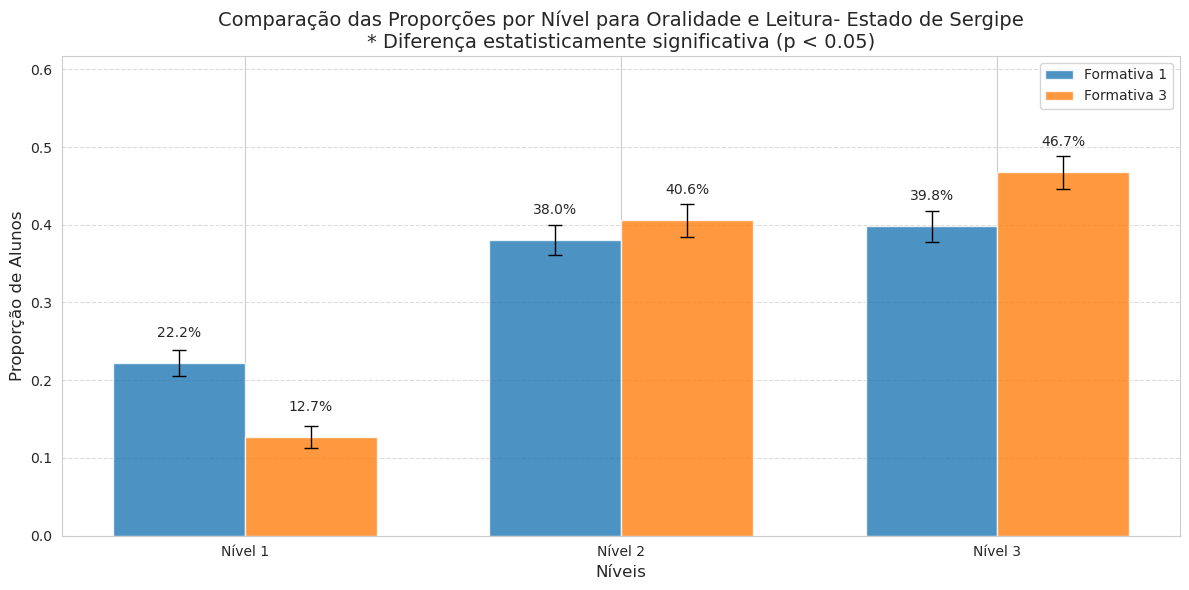

In [23]:
## Calcular proporções para cada nível em cada teste
for nivel in ['Nível 1', 'Nível 2', 'Nível 3']:
    df_oralidade_leitura[f'prop_form_1_{nivel}'] = df_oralidade_leitura[f'form_1_{nivel}'] / df_oralidade_leitura['total_alunos_form_1']
    df_oralidade_leitura[f'prop_form_3_{nivel}'] = df_oralidade_leitura[f'form_3_{nivel}'] / df_oralidade_leitura['total_alunos_form_3']

# 1. Análise para todo o estado
print("\n=== ANÁLISE CONSIDERANDO ORALIDADE E LEITURA PARA TODO O ESTADO DE SERGIPE ===\n")

# Teste de Wilcoxon para amostras pareadas (comparando as proporções de cada turma)
for nivel in ['Nível 1', 'Nível 2', 'Nível 3']:
    stat, p = wilcoxon(df_oralidade_leitura[f'prop_form_1_{nivel}'], 
                       df_oralidade_leitura[f'prop_form_3_{nivel}'])
    print(f"Teste de Wilcoxon para {nivel}:")
    print(f"Estatística = {stat:.3f}, p-valor = {p:.4f}")
    if p < 0.05:
        print(f"Há diferença significativa (p < 0.05) nas proporções de {nivel} entre os testes.")
        # Verificar a direção da diferença
        median_diff = (df_oralidade_leitura[f'prop_form_3_{nivel}'] - df_oralidade_leitura[f'prop_form_1_{nivel}']).median()
        if median_diff > 0:
            print(f"A proporção de alunos no {nivel} AUMENTOU significativamente no teste 2.")
        else:
            print(f"A proporção de alunos no {nivel} DIMINUIU significativamente no teste 2.")
    else:
        print(f"Não há diferença significativa (p ≥ 0.05) nas proporções de {nivel} entre os testes.")
    print("---")

# 2. Análise por município
print("\n=== ANÁLISE CONSIDERANDO ORALIDADE E LEITURA POR MUNICÍPIO ===\n")

for municipio in df_oralidade_leitura['municipio'].unique():
    print(f"\nMunicípio: {municipio}")
    df_municipio = df_oralidade_leitura[df_oralidade_leitura['municipio'] == municipio]
    
    if len(df_municipio) < 3:  # Muito poucas turmas para análise
        print("Número de turmas insuficiente para análise estatística.")
        continue
    
    for nivel in ['Nível 1', 'Nível 2', 'Nível 3']:
        stat, p = wilcoxon(df_municipio[f'prop_form_1_{nivel}'], 
                           df_municipio[f'prop_form_3_{nivel}'])
        print(f"\n{nivel}:")
        print(f"Estatística = {stat:.3f}, p-valor = {p:.4f}")
        if p < 0.05:
            print(f"Há diferença significativa (p < 0.05) em {municipio}.")
            median_diff = (df_municipio[f'prop_form_3_{nivel}'] - df_municipio[f'prop_form_1_{nivel}']).median()
            if median_diff > 0:
                print(f"A proporção de alunos no {nivel} AUMENTOU significativamente no teste 2.")
            else:
                print(f"A proporção de alunos no {nivel} DIMINUIU significativamente no teste 2.")
        else:
            print(f"Não há diferença significativa (p ≥ 0.05) em {municipio}.")

# 3. Análise de transição entre níveis (para todo o estado)
print("\n=== ANÁLISE DE TRANSIÇÃO ENTRE NÍVEIS PARA ORALIDADE E LEITURA (ESTADO) ===\n")

# Calcular totais estaduais para cada nível
totais_estado = {
    'form_1_Nível 1': df_oralidade_leitura['form_1_Nível 1'].sum(),
    'form_1_Nível 2': df_oralidade_leitura['form_1_Nível 2'].sum(),
    'form_1_Nível 3': df_oralidade_leitura['form_1_Nível 3'].sum(),
    'form_3_Nível 1': df_oralidade_leitura['form_3_Nível 1'].sum(),
    'form_3_Nível 2': df_oralidade_leitura['form_3_Nível 2'].sum(),
    'form_3_Nível 3': df_oralidade_leitura['form_3_Nível 3'].sum(),
    'total_form_1': df_oralidade_leitura['total_alunos_form_1'].sum(),
    'total_form_3': df_oralidade_leitura['total_alunos_form_3'].sum()
}

# Teste qui-quadrado para tabelas de contingência (comparando distribuição dos níveis)
print("Teste qui-quadrado para distribuição dos níveis entre form_1 e form_3:")

# Criar tabela de contingência
contingency_table = np.array([
    [totais_estado['form_1_Nível 1'], totais_estado['form_1_Nível 2'], totais_estado['form_1_Nível 3']],
    [totais_estado['form_3_Nível 1'], totais_estado['form_3_Nível 2'], totais_estado['form_3_Nível 3']]
])

chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Qui-quadrado = {chi2:.3f}, p-valor = {p:.4f}")
if p < 0.05:
    print("Há diferença significativa (p < 0.05) na distribuição dos níveis entre os testes.")
    print("Tabela observada:")
    print(contingency_table)
    print("\nTabela esperada sob a hipótese nula:")
    print(expected.round(1))
    
    # Calcular resíduos padronizados para identificar onde estão as diferenças
    residuals = (contingency_table - expected) / np.sqrt(expected)
    print("\nResíduos padronizados (valores absolutos >2 indicam diferenças significativas):")
    print(residuals.round(2))
else:
    print("Não há diferença significativa (p ≥ 0.05) na distribuição dos níveis entre os testes.")

# Visualização dos resultados com barras de erro
plt.figure(figsize=(12, 6))

# Proporções estaduais
prop_form_1 = [totais_estado['form_1_Nível 1']/totais_estado['total_form_1'],
               totais_estado['form_1_Nível 2']/totais_estado['total_form_1'],
               totais_estado['form_1_Nível 3']/totais_estado['total_form_1']]

prop_form_3 = [totais_estado['form_3_Nível 1']/totais_estado['total_form_3'],
               totais_estado['form_3_Nível 2']/totais_estado['total_form_3'],
               totais_estado['form_3_Nível 3']/totais_estado['total_form_3']]

# Calcular erros padrão para cada proporção
# Para proporções, o erro padrão é sqrt(p*(1-p)/n)
def calc_erro_proporcao(p, n):
    return np.sqrt(p * (1 - p) / n)

erro_form_1 = [calc_erro_proporcao(p, totais_estado['total_form_1']) for p in prop_form_1]
erro_form_3 = [calc_erro_proporcao(p, totais_estado['total_form_3']) for p in prop_form_3]

bar_width = 0.35
index = np.arange(3)

# Criar barras com erro
bars1 = plt.bar(index, prop_form_1, bar_width, label='Formativa 1', alpha=0.8, color='#1f77b4',
               yerr=erro_form_1, capsize=5, error_kw={'elinewidth': 1, 'capthick': 1})

bars2 = plt.bar(index + bar_width, prop_form_3, bar_width, label='Formativa 3', alpha=0.8, color='#ff7f0e',
               yerr=erro_form_3, capsize=5, error_kw={'elinewidth': 1, 'capthick': 1})

# Adicionar valores nas barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.03,  # Adicione um offset de 0.02 (2%)
                f'{height:.1%}',
                ha='center', va='bottom', fontsize=10)

# Testar cada nível separadamente com Wilcoxon
niveis_significativos = []
for i, nivel in enumerate(['Nível 1', 'Nível 2', 'Nível 3']):
    stat, p_nivel = wilcoxon(df_oralidade_leitura[f'prop_form_1_{nivel}'], 
                            df_oralidade_leitura[f'prop_form_3_{nivel}'])
    if p_nivel < 0.05:
        niveis_significativos.append(i)
        y_pos = max(prop_form_1[i], prop_form_2[i]) + 0.05
        plt.text(index[i] + bar_width/2, y_pos, '*', 
                ha='center', va='bottom', fontsize=16, color='red')

# Personalizar
plt.xlabel('Níveis', fontsize=12)
plt.ylabel('Proporção de Alunos', fontsize=12)
plt.title('Comparação das Proporções por Nível para Oralidade e Leitura- Estado de Sergipe\n* Diferença estatisticamente significativa (p < 0.05)', fontsize=14)
plt.xticks(index + bar_width/2, ['Nível 1', 'Nível 2', 'Nível 3'])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, max(prop_form_1 + prop_form_3) + 0.15)  # Ajuste para acomodar as barras de erro

# Salvando gráfico
plt.savefig(f'{output_dir_relatorio_21}/teste_wilcoxon_oralidade_leitura_sergipe.png', dpi=300)

# Exibindo gráfico
plt.tight_layout()
plt.show()


In [24]:
# Testando Oralidade e Leitura e criando gráficos para cada município
# Função para criar e salvar gráficos por município
def criar_graficos_municipios(df, output_dir):
    # Agrupar dados por município
    grouped = df.groupby('municipio')
    
    for municipio, group in grouped:
        # Calcular totais para o município
        totais_municipio = {
            'form_1_Nível 1': group['form_1_Nível 1'].sum(),
            'form_1_Nível 2': group['form_1_Nível 2'].sum(),
            'form_1_Nível 3': group['form_1_Nível 3'].sum(),
            'form_3_Nível 1': group['form_3_Nível 1'].sum(),
            'form_3_Nível 2': group['form_3_Nível 2'].sum(),
            'form_3_Nível 3': group['form_3_Nível 3'].sum(),
            'total_form_1': group['total_alunos_form_1'].sum(),
            'total_form_3': group['total_alunos_form_3'].sum()
        }
        
        # Calcular proporções
        prop_form_1 = [
            totais_municipio['form_1_Nível 1']/totais_municipio['total_form_1'],
            totais_municipio['form_1_Nível 2']/totais_municipio['total_form_1'],
            totais_municipio['form_1_Nível 3']/totais_municipio['total_form_1']
        ]
        
        prop_form_3 = [
            totais_municipio['form_3_Nível 1']/totais_municipio['total_form_3'],
            totais_municipio['form_3_Nível 2']/totais_municipio['total_form_3'],
            totais_municipio['form_3_Nível 3']/totais_municipio['total_form_3']
        ]
        
        # Calcular erros padrão
        def calc_erro(p, n):
            return np.sqrt(p * (1 - p) / n) if n > 0 else 0
            
        erro_form_1 = [calc_erro(p, totais_municipio['total_form_1']) for p in prop_form_1]
        erro_form_2 = [calc_erro(p, totais_municipio['total_form_3']) for p in prop_form_2]
        
        # Criar figura
        plt.figure(figsize=(10, 6))
        
        # Configurações do gráfico
        bar_width = 0.35
        index = np.arange(3)
        
        # Criar barras
        bars1 = plt.bar(index, prop_form_1, bar_width, label='Formativa 1', color='#1f77b4',
                       yerr=erro_form_1, capsize=5, alpha=0.7)
        bars2 = plt.bar(index + bar_width, prop_form_2, bar_width, label='Formativa 3', color='#ff7f0e',
                       yerr=erro_form_2, capsize=5, alpha=0.7)
        
        # Adicionar valores nas barras
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                plt.text(bar.get_x() + bar.get_width()/2., height + 0.03,
                         f'{height:.1%}',
                         ha='center', va='bottom', fontsize=9)
        
        # Verificar significância por nível
        niveis_significativos = []
        for i, nivel in enumerate(['Nível 1', 'Nível 2', 'Nível 3']):
            if len(group) >= 3:  # Só testar se tiver turmas suficientes
                stat, p_nivel = wilcoxon(group[f'prop_form_1_{nivel}'], 
                                        group[f'prop_form_3_{nivel}'])
                if p_nivel < 0.05:
                    niveis_significativos.append(i)
                    y_pos = max(prop_form_1[i], prop_form_2[i]) + 0.05
                    plt.text(index[i] + bar_width/2, y_pos, '*', 
                            ha='center', va='bottom', fontsize=14, color='red')
            
        plt.xlabel('Níveis', fontsize=10)
        plt.ylabel('Proporção de Alunos', fontsize=10)
        plt.title(f'Comparação das Proporções por Nível para Oralidade e Leitura - {municipio}\n* Diferença estatisticamente significativa (p < 0.05)', fontsize=12)
        plt.xticks(index + bar_width/2, ['Nível 1', 'Nível 2', 'Nível 3'])
        plt.legend()
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        
        # Ajustar layout e salvar
        plt.tight_layout()
        
        # Criar nome do arquivo (substituir caracteres inválidos)
        filename = f"teste_wilcoxon_oralidade_leitura_{municipio.replace(' ', '_').replace('/', '_')}.png"
        filepath = os.path.join(output_dir_relatorio_21, filename)
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        plt.close()
        
        print(f"Gráfico salvo em: {filepath}")

# Chamar a função para criar os gráficos
criar_graficos_municipios(df_oralidade_leitura, output_dir)

Gráfico salvo em: Data_files/graficos_relatorio_2.1/teste_wilcoxon_oralidade_leitura_Aracaju.png
Gráfico salvo em: Data_files/graficos_relatorio_2.1/teste_wilcoxon_oralidade_leitura_Capela.png
Gráfico salvo em: Data_files/graficos_relatorio_2.1/teste_wilcoxon_oralidade_leitura_Itabaianinha.png
Gráfico salvo em: Data_files/graficos_relatorio_2.1/teste_wilcoxon_oralidade_leitura_Japoatã.png
Gráfico salvo em: Data_files/graficos_relatorio_2.1/teste_wilcoxon_oralidade_leitura_Lagarto.png
Gráfico salvo em: Data_files/graficos_relatorio_2.1/teste_wilcoxon_oralidade_leitura_Monte_Alegre_de_Sergipe.png
Gráfico salvo em: Data_files/graficos_relatorio_2.1/teste_wilcoxon_oralidade_leitura_Neópolis.png
Gráfico salvo em: Data_files/graficos_relatorio_2.1/teste_wilcoxon_oralidade_leitura_Pacatuba.png
Gráfico salvo em: Data_files/graficos_relatorio_2.1/teste_wilcoxon_oralidade_leitura_Porto_da_Folha.png
Gráfico salvo em: Data_files/graficos_relatorio_2.1/teste_wilcoxon_oralidade_leitura_Poço_Redondo.